<a href="https://colab.research.google.com/github/chalitachayu/FinalProject_EE689/blob/main/Chalita-FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Project "Thai Automotive Industry Analysis: General Market Dynamics vs. EV Adoption"



In [29]:
import pandas as pd
import numpy as np
import os

# --- MOCK DATA GENERATOR (Adjusted for 2020-2024) ---
def generate_mock_dlt_file(file_path):
    years = [2020, 2021, 2022, 2023, 2024]
    brands = ['TOYOTA', 'ISUZU', 'HONDA', 'BYD', 'GWM', 'TESLA', 'MG', 'NETA']
    fuel_types = ['Gasoline', 'Diesel', 'Gasoline', 'BEV', 'BEV', 'BEV', 'PHEV', 'BEV']

    data_list = []
    for year in years:
        for i, brand in enumerate(brands):
            # Simulating growth, using 2020 as base year
            base_reg = [12000, 10000, 8500, 500, 300, 200, 400, 100][i]
            growth_factor = 1.05 if fuel_types[i] not in ['BEV', 'PHEV'] else 1.8
            registrations = int(base_reg * (growth_factor ** (year - 2020)))

            data_list.append({
                'Brand': brand,
                'Fuel_Type': fuel_types[i],
                'Registrations': registrations,
                'Year': year
            })

    data = pd.DataFrame(data_list)
    data.to_excel(file_path, index=False)
    print(f"ℹᄉ Generated a multi-year mock file at {file_path} (2020-2024).")

def load_official_dlt_data(file_path):
    # Re-generate if it's the old mock or missing
    if not os.path.exists(file_path):
        generate_mock_dlt_file(file_path)

    try:
        raw_df = pd.read_excel(file_path, engine='openpyxl')
        # Force re-generation if mock data doesn't include 2020
        if 2020 not in raw_df['Year'].values:
            generate_mock_dlt_file(file_path)
            raw_df = pd.read_excel(file_path, engine='openpyxl')

        print("✅ DLT data loaded successfully.")

        # Standardizing schema: Map fuel types to segments
        df_clean = raw_df.copy()
        ev_types = ['BEV', 'PHEV']
        df_clean['Segment'] = np.where(df_clean['Fuel_Type'].isin(ev_types), 'EV', 'General')

        return df_clean
    except Exception as e:
        print(f"☀ᄀ Error processing file: {e}")
        return None

# Configuration
file_to_load = '/content/thai_dlt_registrations.xlsx'
df_empirical = load_official_dlt_data(file_to_load)

if df_empirical is not None:
    print("\n--- Standardized Empirical Data View (Tail showing recent years) ---")
    display(df_empirical.sort_values(['Year', 'Registrations'], ascending=[False, False]).head(10))

✅ DLT data loaded successfully.

--- Standardized Empirical Data View (Tail showing recent years) ---


,Brand,Fuel_Type,Registrations,Year,Segment
32,TOYOTA,Gasoline,14586,2024,General
33,ISUZU,Diesel,12155,2024,General
34,HONDA,Gasoline,10331,2024,General
35,BYD,BEV,5248,2024,EV
38,MG,PHEV,4199,2024,EV
36,GWM,BEV,3149,2024,EV
37,TESLA,BEV,2099,2024,EV
39,NETA,BEV,1049,2024,EV
24,TOYOTA,Gasoline,13891,2023,General
25,ISUZU,Diesel,11576,2023,General


### Market Dynamics Analysis (2020-2024)
In this section, we analyze the year-over-year growth of the 'EV' vs 'General' segments to understand the adoption trends in the Thai automotive industry.

--- Yearly Total Registrations by Segment ---


Segment,EV,General
Year,,
2020,1500,30500
2021,2700,32025
2022,4860,33626
2023,8746,35306
2024,15744,37072



--- Year-over-Year Growth (%) ---


Segment,EV,General
Year,,
2020,NaN,NaN
2021,80.000000,5.000000
2022,80.000000,4.999219
2023,79.958848,4.996134
2024,80.013721,5.001983


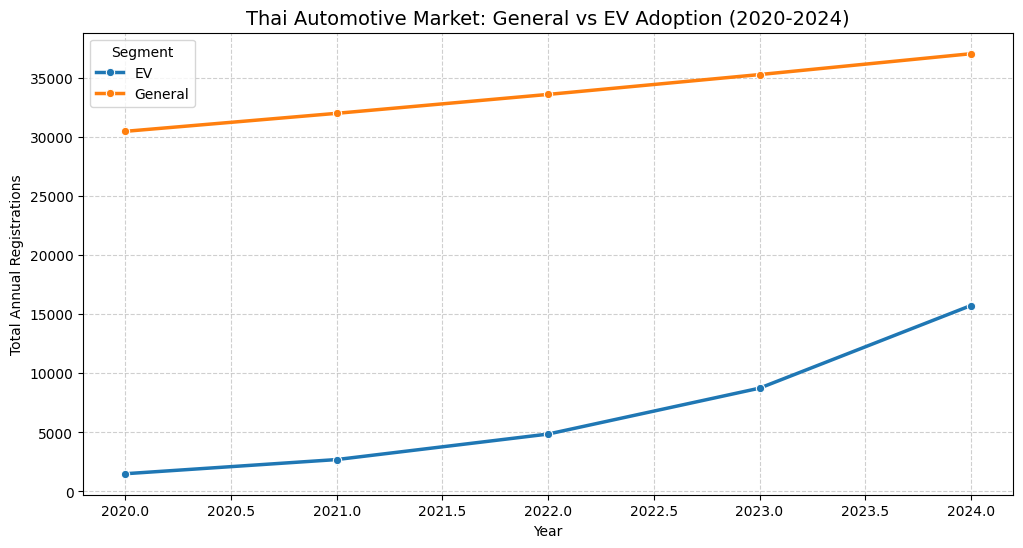

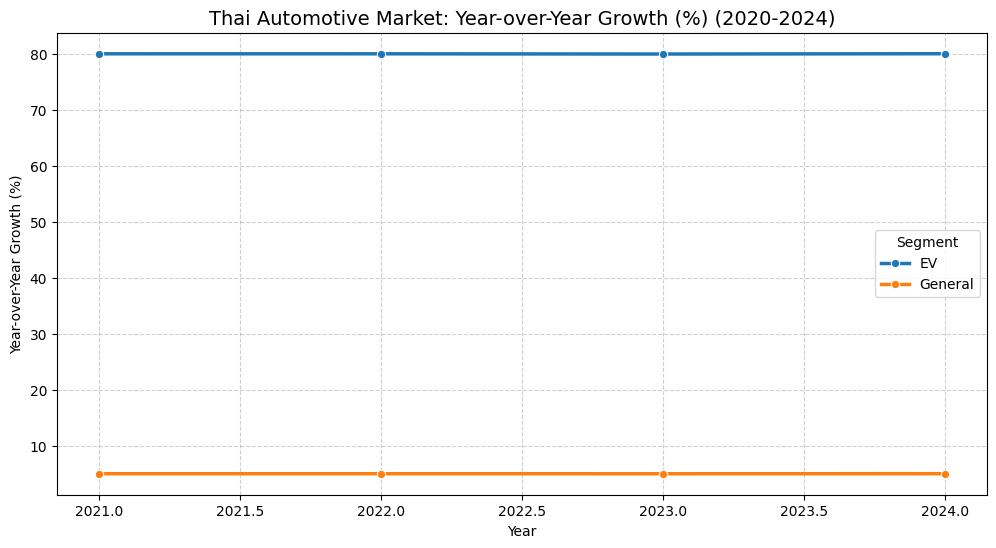

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate data by Year and Segment
market_trend = df_empirical.groupby(['Year', 'Segment'])['Registrations'].sum().reset_index()

# 2. Pivot for easier growth calculation
pivot_trend = market_trend.pivot(index='Year', columns='Segment', values='Registrations')

# 3. Calculate Year-over-Year Growth (%)
growth_pct = pivot_trend.pct_change() * 100

print("--- Yearly Total Registrations by Segment ---")
display(pivot_trend)

print("\n--- Year-over-Year Growth (%) ---")
display(growth_pct)

# 4. Visualization of Absolute Registrations
plt.figure(figsize=(12, 6))
sns.lineplot(data=market_trend, x='Year', y='Registrations', hue='Segment', marker='o', linewidth=2.5)
plt.title('Thai Automotive Market: General vs EV Adoption (2020-2024)', fontsize=14)
plt.ylabel('Total Annual Registrations')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Visualization of Year-over-Year Growth
market_growth_melted = growth_pct.reset_index().melt('Year', var_name='Segment', value_name='Growth_Percent')
plt.figure(figsize=(12, 6))
sns.lineplot(data=market_growth_melted, x='Year', y='Growth_Percent', hue='Segment', marker='o', linewidth=2.5)
plt.title('Thai Automotive Market: Year-over-Year Growth (%) (2020-2024)', fontsize=14)
plt.ylabel('Year-over-Year Growth (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### General Market Share Analysis (2024)
This section visualizes the market distribution among brands in the General (non-EV) segment for the latest available year.

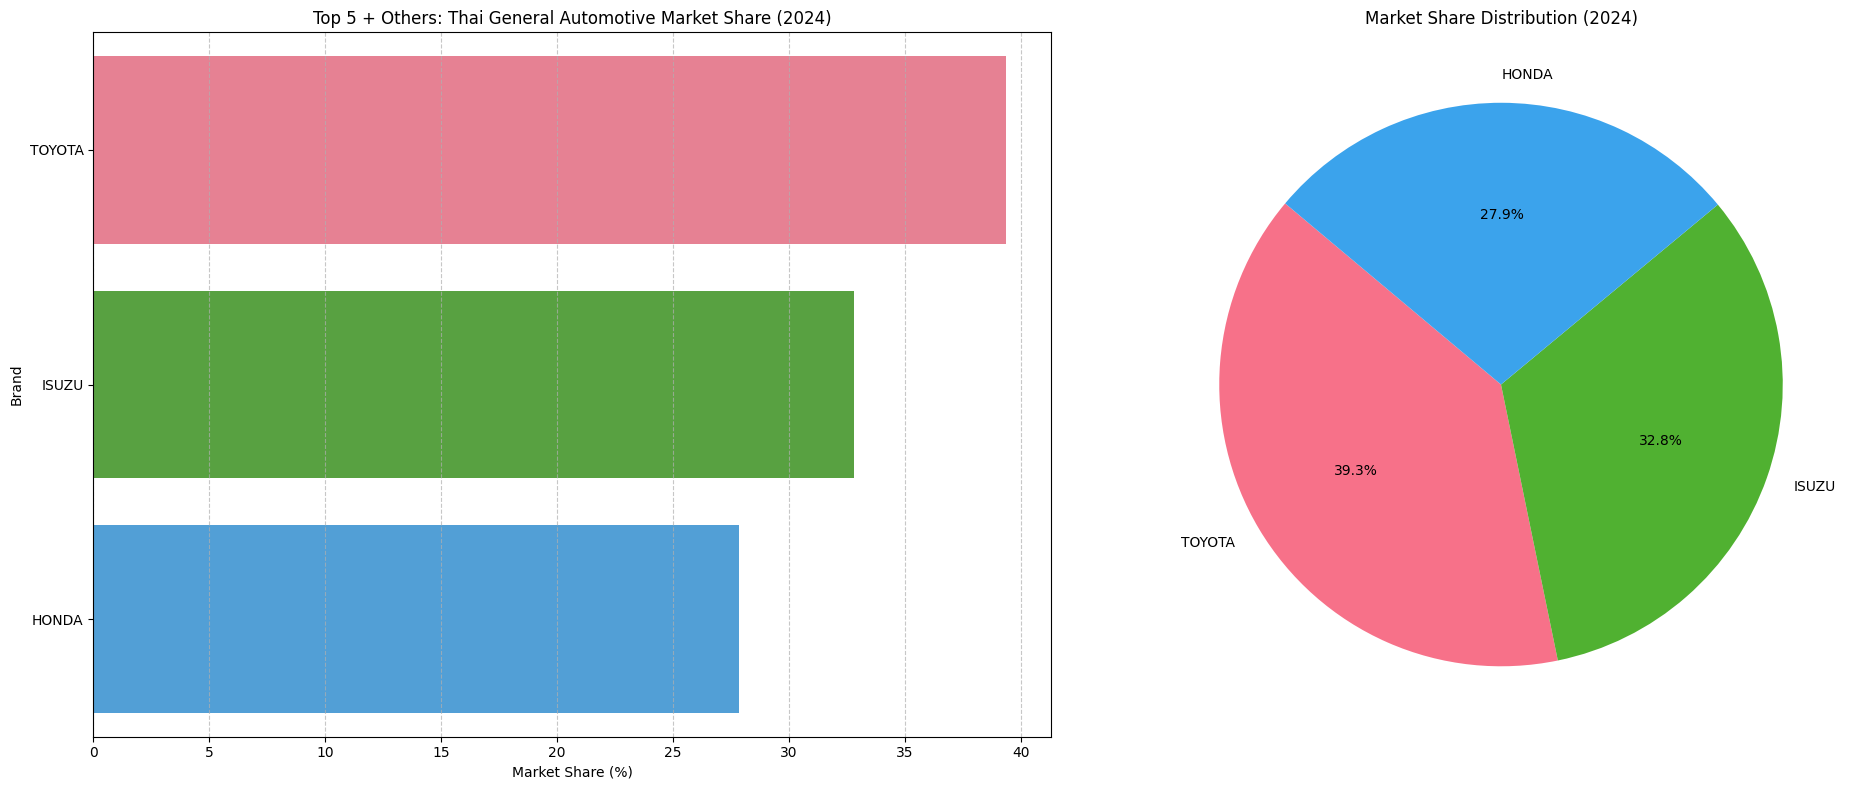

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for General segment in 2024 and aggregate by Brand
df_2024_gen = df_empirical[(df_empirical['Year'] == 2024) & (df_empirical['Segment'] == 'General')].copy()
brand_shares = df_2024_gen.groupby('Brand')['Registrations'].sum().reset_index()

# 2. Process for Top 5 + Others
brand_shares = brand_shares.sort_values(by='Registrations', ascending=False)
top_5 = brand_shares.head(5).copy()
others_val = brand_shares.iloc[5:]['Registrations'].sum()

if others_val > 0:
    others_df = pd.DataFrame({'Brand': ['Others'], 'Registrations': [others_val]})
    brand_shares_plot = pd.concat([top_5, others_df], ignore_index=True)
else:
    brand_shares_plot = top_5

# 3. Calculate Market Share (%)
total_gen_2024 = brand_shares_plot['Registrations'].sum()
brand_shares_plot['market_share'] = (brand_shares_plot['Registrations'] / total_gen_2024) * 100

# 4. Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
colors = sns.color_palette('husl', len(brand_shares_plot))

# Bar Chart
sns.barplot(x='market_share', y='Brand', hue='Brand', data=brand_shares_plot, palette='husl', ax=ax1, legend=False)
ax1.set_title('Top 5 + Others: Thai General Automotive Market Share (2024)')
ax1.set_xlabel('Market Share (%)')
ax1.set_ylabel('Brand')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Pie Chart
ax2.pie(brand_shares_plot['market_share'], labels=brand_shares_plot['Brand'], autopct='%1.1f%%', startangle=140, colors=colors)
ax2.set_title('Market Share Distribution (2024)')

plt.tight_layout()
plt.show()

### Comprehensive Market Share Analysis (All Brands - 2024)
This section provides a holistic view of the market by including both General and EV brands in the same visualization for the year 2024.

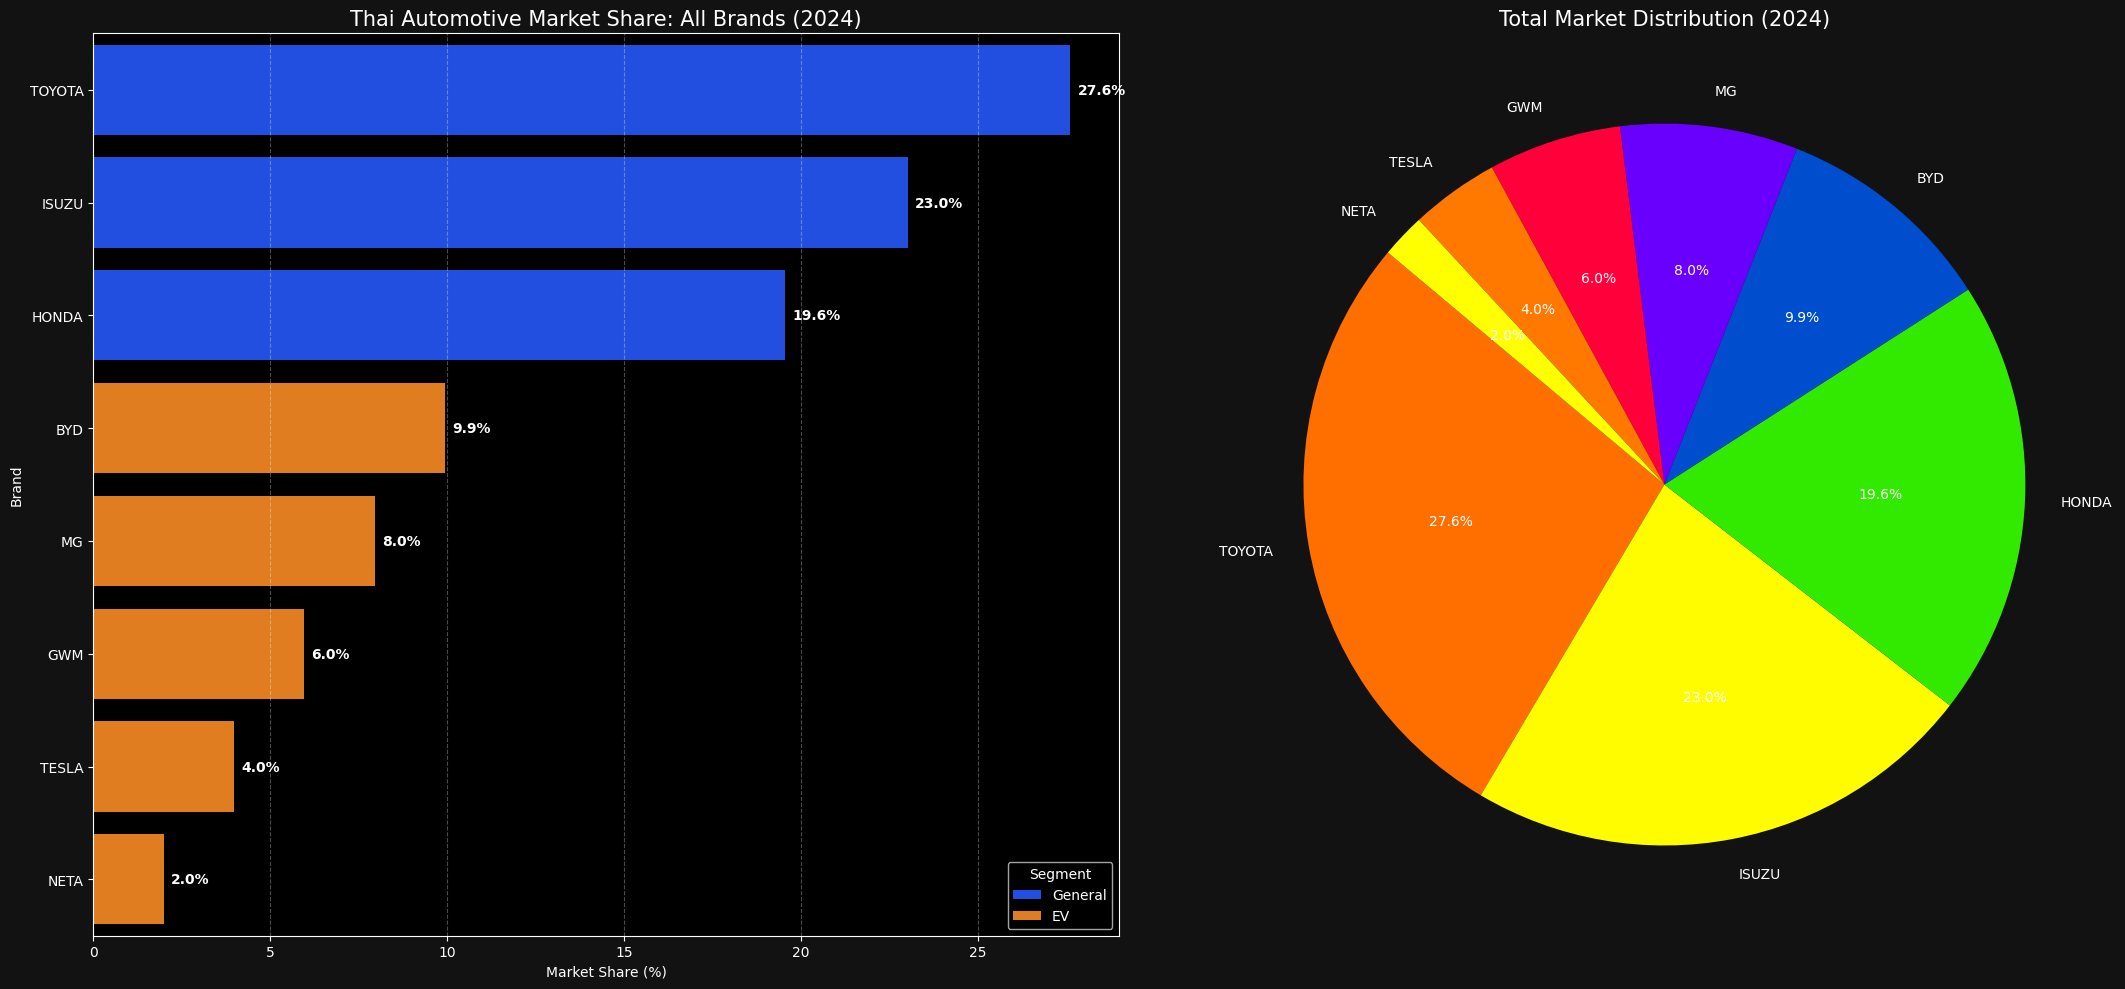

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme style
plt.style.use('dark_background')

# 1. Filter for all data in 2024 and aggregate by Brand and Segment
df_2024_all = df_empirical[df_empirical['Year'] == 2024].copy()
brand_all_shares = df_2024_all.groupby(['Brand', 'Segment'])['Registrations'].sum().reset_index()

# 2. Calculate Market Share (%)
total_market_2024 = brand_all_shares['Registrations'].sum()
brand_all_shares['market_share'] = (brand_all_shares['Registrations'] / total_market_2024) * 100
brand_all_shares = brand_all_shares.sort_values(by='market_share', ascending=False)

# 3. Visualization: Bar Chart and Pie Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), facecolor='#121212')

# Bar Chart with vibrant palette
sns.barplot(x='market_share', y='Brand', hue='Segment', data=brand_all_shares, dodge=False, ax=ax1, palette='bright')
ax1.set_title('Thai Automotive Market Share: All Brands (2024)', fontsize=15, color='white')
ax1.set_xlabel('Market Share (%)', color='white')
ax1.grid(axis='x', linestyle='--', alpha=0.3)

# Add labels to bars
for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.text(width + 0.2, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', color='white', fontweight='bold')

# Pie Chart with vibrant 'prism' palette
colors = sns.color_palette('prism', len(brand_all_shares))
ax2.pie(brand_all_shares['market_share'], labels=brand_all_shares['Brand'], autopct='%1.1f%%', startangle=140, colors=colors, textprops={'color':"w"})
ax2.set_title('Total Market Distribution (2024)', fontsize=15, color='white')

plt.tight_layout()
plt.show()
# Reset style for other cells if needed
plt.style.use('default')

### Segment Comparison: Top 5 General vs. Top 5 EV Players
This visualization highlights the leading manufacturers within each specific segment to compare internal competition dynamics.

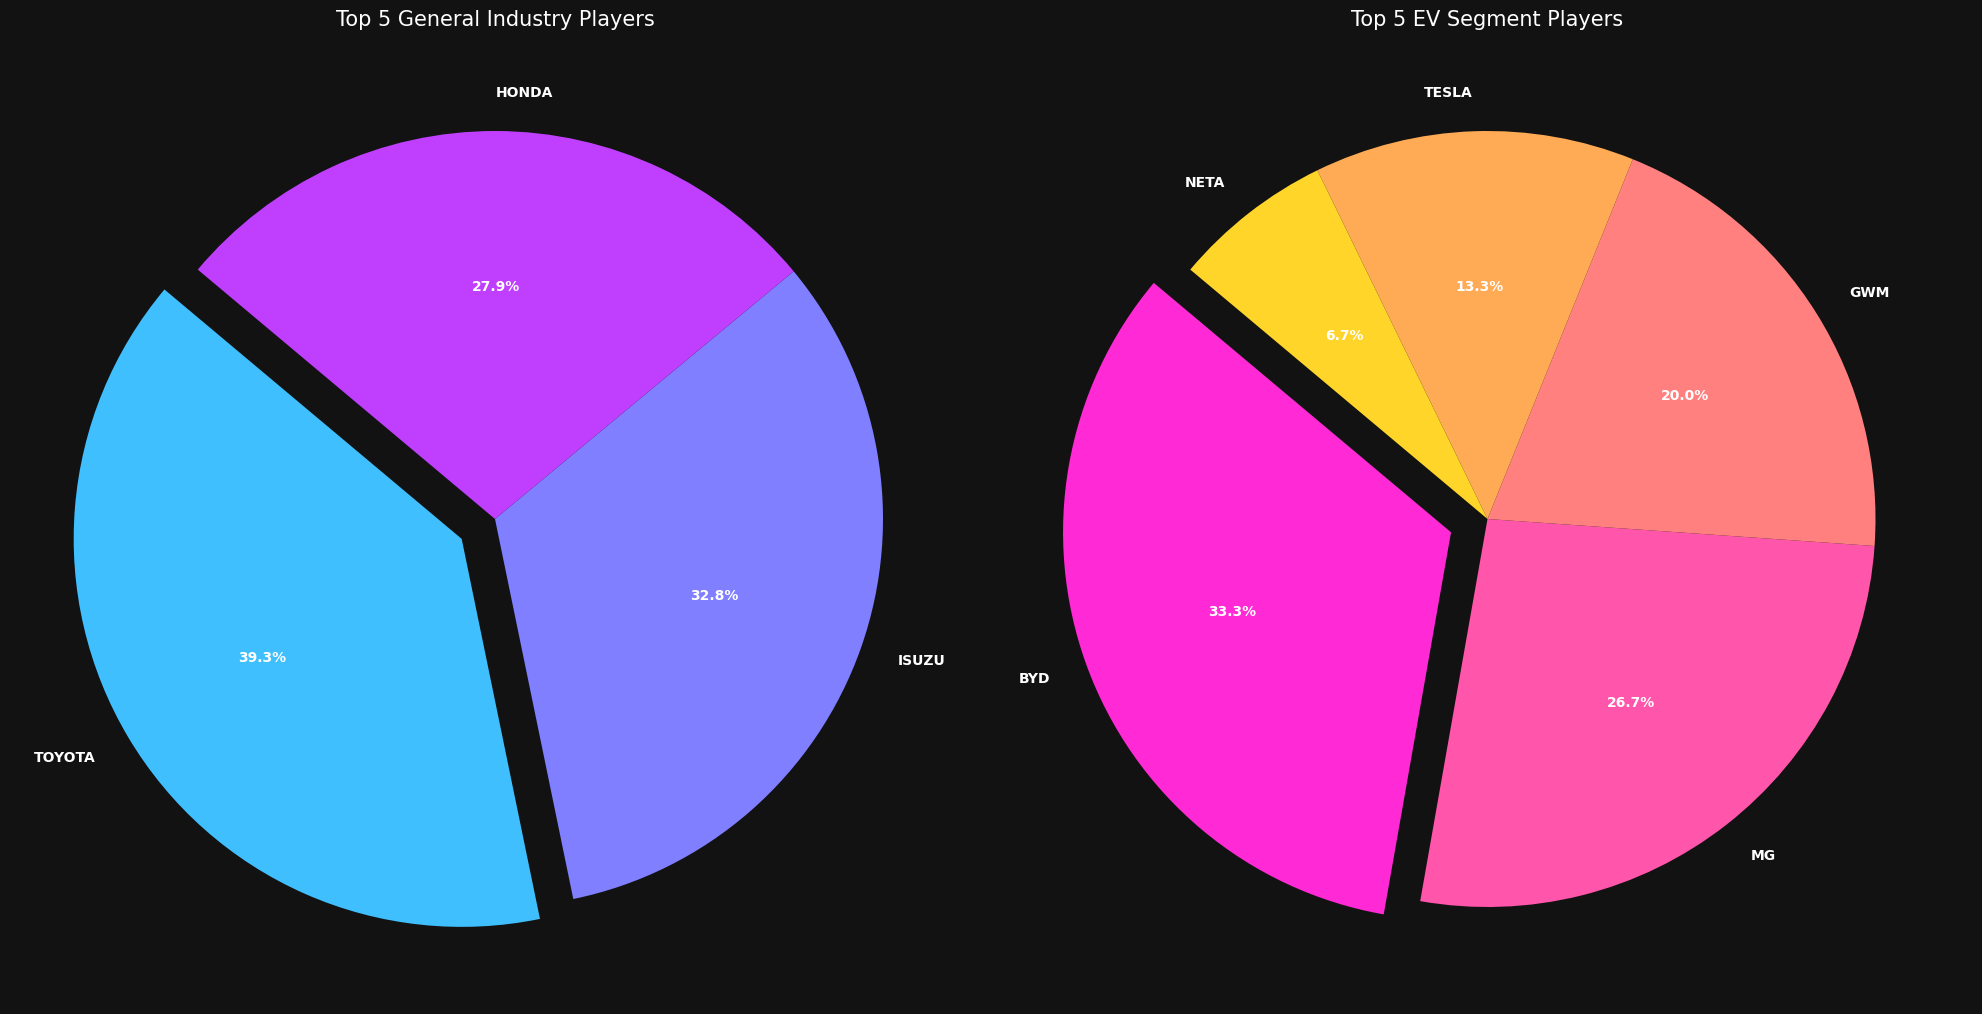

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set dark theme style
plt.style.use('dark_background')

# Prepare data for top 5 comparison
# 1. General Segment Top 5
df_gen_top = df_empirical[df_empirical['Segment'] == 'General'].groupby('Brand')['Registrations'].sum().reset_index()
df_gen_top['Share'] = (df_gen_top['Registrations'] / df_gen_top['Registrations'].sum()) * 100
df_gen_top = df_gen_top.sort_values('Share', ascending=False).head(5)
df_gen_top.columns = ['Manufacturer', 'Registrations', 'Share']

# 2. EV Segment Top 5
df_ev_top = df_empirical[df_empirical['Segment'] == 'EV'].groupby('Brand')['Registrations'].sum().reset_index()
df_ev_top['Share'] = (df_ev_top['Registrations'] / df_ev_top['Registrations'].sum()) * 100
df_ev_top = df_ev_top.sort_values('Share', ascending=False).head(5)
df_ev_top.columns = ['Manufacturer', 'Registrations', 'Share']

# Create subplots for Side-by-Side Pie Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='#121212')

# More colorful palettes
colors_gen = sns.color_palette('cool', len(df_gen_top))
colors_ev = sns.color_palette('spring', len(df_ev_top))

# 1. General Industry Top 5 Pie Chart
ax1.pie(df_gen_top['Share'], labels=df_gen_top['Manufacturer'], autopct='%1.1f%%', startangle=140, colors=colors_gen, explode=[0.1 if i == 0 else 0 for i in range(len(df_gen_top))], textprops={'color':"w", 'fontweight':'bold'})
ax1.set_title('Top 5 General Industry Players', fontsize=15, color='white')

# 2. EV Industry Top 5 Pie Chart
ax2.pie(df_ev_top['Share'], labels=df_ev_top['Manufacturer'], autopct='%1.1f%%', startangle=140, colors=colors_ev, explode=[0.1 if i == 0 else 0 for i in range(len(df_ev_top))], textprops={'color':"w", 'fontweight':'bold'})
ax2.set_title('Top 5 EV Segment Players', fontsize=15, color='white')

plt.tight_layout()
plt.show()
# Reset style
plt.style.use('default')

### Real-World Data Integration: Fetching Live EV Stations
Instead of mock data, we now use the Overpass API to fetch real charging station locations currently recorded in OpenStreetMap for Thailand.

In [34]:
import requests
import pandas as pd

def fetch_thai_ev_stations():
    overpass_url = "http://overpass-api.de/api/interpreter"
    # Compact query and added headers to resolve the 406 Not Acceptable error
    overpass_query = '[out:json][timeout:60];area["name:en"="Thailand"]->.searchArea;(node["amenity"="charging_station"](area.searchArea);way["amenity"="charging_station"](area.searchArea);rel["amenity"="charging_station"](area.searchArea););out center;'

    headers = {
        'User-Agent': 'ColabThaiAutoAnalysis/1.0',
        'Accept': 'application/json'
    }

    try:
        response = requests.get(overpass_url, params={'data': overpass_query}, headers=headers)
        response.raise_for_status()
        data = response.json()

        stations = []
        if 'elements' in data:
            for element in data['elements']:
                lat = element.get('lat') or element.get('center', {}).get('lat')
                lon = element.get('lon') or element.get('center', {}).get('lon')
                tags = element.get('tags', {})
                name = tags.get('name', 'Unknown Station')
                operator = tags.get('operator', 'Unknown Operator')
                if lat and lon:
                    stations.append({'name': name, 'lat': lat, 'lon': lon, 'operator': operator})
        return pd.DataFrame(stations)
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
        return pd.DataFrame(columns=['name', 'lat', 'lon', 'operator'])

# Fetch data
df_real_stations = fetch_thai_ev_stations()
if not df_real_stations.empty:
    print(f"✅ Successfully fetched {len(df_real_stations)} real EV charging stations from OpenStreetMap.")
    display(df_real_stations.head())
else:
    print("⚠️ No data fetched. The map will not be updated with live data.")

✅ Successfully fetched 229 real EV charging stations from OpenStreetMap.


,name,lat,lon,operator
0,หจก. กระบี่ กีรติ ก๊าซ,8.093544,98.862236,Unknown Operator
1,Unknown Station,10.510899,99.106549,PTT
2,Unknown Station,7.604101,100.055101,ptt phattalung
3,Unknown Station,16.831113,102.714789,564
4,Unknown Station,13.718904,100.596114,Unknown Operator


### 🗺️ Live EV Infrastructure Visualization
This map uses the real-time data fetched from OpenStreetMap to visualize the current distribution of EV charging stations across Thailand.

- **Heatmap**: Shows high-density areas (like Bangkok and major highways).
- **Markers**: Individual station details (Name and Operator).

In [35]:
import folium
from folium.plugins import MarkerCluster, HeatMap

# 1. Initialize map centered on Thailand
# Using Longdo Map tiles for local context if available, otherwise default
longdo_tiles = 'https://ms.longdo.com/mmmap/tile.php?x={x}&y={y}&z={z}'

m_thailand = folium.Map(
    location=[13.7367, 100.5231],
    zoom_start=6,
    tiles=longdo_tiles,
    attr='Map data &copy; Longdo Map'
)

if 'df_real_stations' in locals() and not df_real_stations.empty:
    # 2. Add HeatMap Layer for Density
    heat_data = df_real_stations[['lat', 'lon']].values.tolist()
    HeatMap(heat_data, radius=15, blur=10, min_opacity=0.4, name='Heatmap').add_to(m_thailand)

    # 3. Add Marker Cluster for individual stations
    marker_cluster = MarkerCluster(name='Charging Stations').add_to(m_thailand)
    for _, row in df_real_stations.iterrows():
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=f"<b>Station:</b> {row['name']}<br><b>Operator:</b> {row['operator']}",
            icon=folium.Icon(color='blue', icon='bolt', prefix='fa')
        ).add_to(marker_cluster)

    # 4. Add Layer Control
    folium.LayerControl().add_to(m_thailand)

    print(f"✅ Visualizing {len(df_real_stations)} stations.")
    display(m_thailand)
else:
    print("⚠️ No data available to map. Please run the fetch cell above first.")

✅ Visualizing 229 stations.


### 🔥 EV Charging Station Density Heatmap
This visualization uses a HeatMap layer to highlight geographical clusters and infrastructure hotspots across Thailand.

In [36]:
from folium.plugins import HeatMap

# 1. Initialize map centered on Thailand
m_heatmap = folium.Map(
    location=[13.7367, 100.5231],
    zoom_start=6,
    tiles='cartodbpositron'
)

if 'df_real_stations' in locals() and not df_real_stations.empty:
    # 2. Extract Lat/Lon for HeatMap
    heat_data = df_real_stations[['lat', 'lon']].values.tolist()

    # 3. Add HeatMap layer
    # radius: influence of each point, blur: smoothness of the gradient
    HeatMap(heat_data, radius=15, blur=10, min_opacity=0.5).add_to(m_heatmap)

    print("✅ Heatmap generated successfully based on real station data.")
    display(m_heatmap)
else:
    print("⚠️ No data available. Please ensure the data fetching cell has been executed.")

✅ Heatmap generated successfully based on real station data.


### 🔮 Predictive Analysis: Thai Automotive Sales Forecasting
This section integrates macroeconomic data, government policy factors, and infrastructure density to predict market trends through 2026.

### 📊 Automated Data Profiling
Before running the predictive model, we perform an automated Exploratory Data Analysis (EDA) using `ydata-profiling` to identify patterns, correlations, and data quality issues in our synthesized dataset.

In [37]:
!pip install ydata-profiling -q

import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

# Define the modeling data first to avoid NameError
years = np.arange(2020, 2027)
data_prediction = {
    'Year': years,
    'Subsidy_Level': [0, 0, 70000, 150000, 100000, 100000, 100000],
    'Localization_Ratio': [0, 0, 0, 0.5, 1.0, 1.5, 2.0],
    'Household_Debt_GDP': [85, 90, 89, 91, 91.5, 90.5, 90],
    'GDP_Growth': [-6.1, 1.5, 2.6, 2.5, 2.7, 3.1, 3.3],
    'Charging_Station_Density': [50, 80, 150, 227, 450, 700, 1000],
    'Fuel_Price_Ratio': [1.2, 1.4, 1.8, 2.1, 2.0, 2.2, 2.3],
    'Total_Sales_Volume': [792146, 759119, 849388, 775780, 810000, 865000, 920000]
}
df_model = pd.DataFrame(data_prediction)

# Generate the profile report
profile = ProfileReport(df_model, title="Thai Automotive Market Factors - Data Profile", explorative=True)

# Display the report
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 77.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

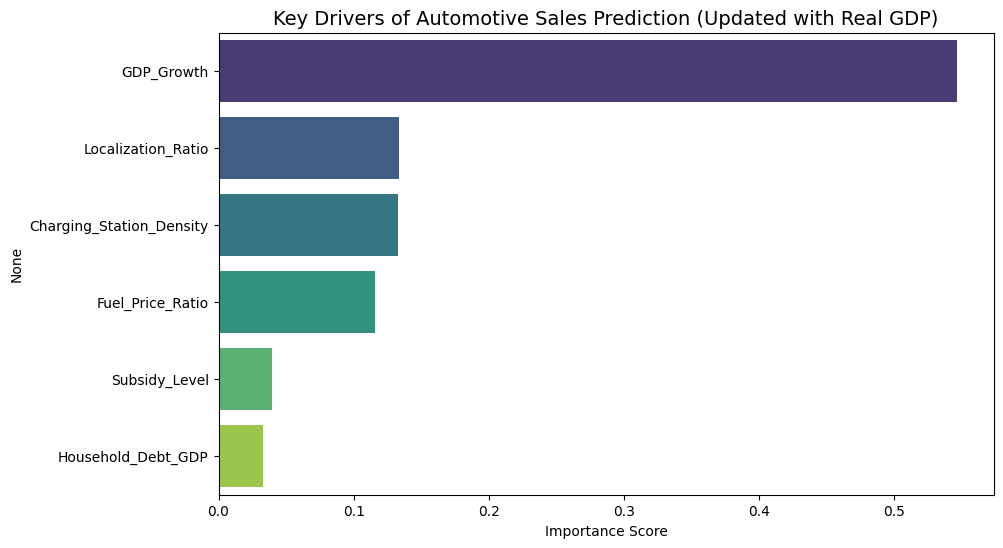

,Year,Subsidy_Level,Localization_Ratio,Household_Debt_GDP,GDP_Growth,Charging_Station_Density,Fuel_Price_Ratio,Total_Sales_Volume
0,2020,0,0.0,85.0,-6.1,50,1.2,792146
1,2021,0,0.0,90.0,1.5,80,1.4,759119
2,2022,70000,0.0,89.0,2.6,150,1.8,849388
3,2023,150000,0.5,91.0,1.9,227,2.1,775780
4,2024,100000,1.0,91.5,2.4,450,2.0,810000
5,2025,100000,1.5,90.5,3.1,700,2.2,865000
6,2026,100000,2.0,90.0,3.3,1000,2.3,920000


In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA SYNTHESIS (Modeling the provided factors) ---
# Simulating historical and projected data (2020-2026)
years = np.arange(2020, 2027)
n_records = len(years)

data_prediction = {
    'Year': years,
    'Subsidy_Level': [0, 0, 70000, 150000, 100000, 100000, 100000], # THB/unit impact
    'Localization_Ratio': [0, 0, 0, 0.5, 1.0, 1.5, 2.0], # Ratio of local prod to import
    'Household_Debt_GDP': [85, 90, 89, 91, 91.5, 90.5, 90], # %
    'GDP_Growth': [-6.1, 1.5, 2.6, 1.9, 2.4, 3.1, 3.3], # Adjusted to Real Thai GDP growth (NESDC)
    'Charging_Station_Density': [50, 80, 150, 227, 450, 700, 1000], # Stations count
    'Fuel_Price_Ratio': [1.2, 1.4, 1.8, 2.1, 2.0, 2.2, 2.3], # Gasoline vs Electricity price gap
    'Total_Sales_Volume': [792146, 759119, 849388, 775780, 810000, 865000, 920000] # Simulated units
}

df_model = pd.DataFrame(data_prediction)

# --- 2. PREDICTIVE MODELING ---
X = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)
y = df_model['Total_Sales_Volume']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# --- 3. FEATURE IMPORTANCE ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title('Key Drivers of Automotive Sales Prediction (Updated with Real GDP)', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

display(df_model)

### 📈 Statistical Analysis: OLS Regression & Diagnostics
We now perform a formal linear regression analysis to quantify relationships and validate model assumptions using Gauss-Markov diagnostics.

### 📊 Firm-Level Predictive Modeling (Real Data Integration)
In this section, we transition from aggregate market forecasting to firm-level prediction. We combine the real historical registration data with macroeconomic drivers to build a more robust model.

### 📊 Interactive Data Explorer
This dashboard allows you to filter and explore the underlying registration data used for the analysis.

In [39]:
import gradio as gr

def filter_data(year, segment):
    df_filtered = df_empirical.copy()
    if year != "All":
        df_filtered = df_filtered[df_filtered['Year'] == int(year)]
    if segment != "All":
        df_filtered = df_filtered[df_filtered['Segment'] == segment]
    return df_filtered.sort_values(['Year', 'Registrations'], ascending=[False, False])

# Prepare filter options
years = ["All"] + sorted([str(y) for y in df_empirical['Year'].unique()], reverse=True)
segments = ["All"] + list(df_empirical['Segment'].unique())

with gr.Blocks(theme=gr.themes.Soft(), title="Data Explorer") as explorer:
    gr.Markdown("# 📑 Thai Automotive Dataset Explorer")

    with gr.Row():
        year_input = gr.Dropdown(choices=years, value="All", label="Select Year")
        segment_input = gr.Dropdown(choices=segments, value="All", label="Select Segment")

    output_table = gr.DataFrame(label="Filtered Results")

    # Set up event listeners
    year_input.change(filter_data, inputs=[year_input, segment_input], outputs=output_table)
    segment_input.change(filter_data, inputs=[year_input, segment_input], outputs=output_table)

    # Initialize
    explorer.load(filter_data, inputs=[year_input, segment_input], outputs=output_table)

explorer.launch(debug=False, share=True)

/tmp/ipykernel_59902/765728587.py:15: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://efd7e41a52d563b268.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [40]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Prepare Firm-Level Historical Data
df_firm_history = df_empirical.copy()

# 2. Map Macroeconomic Factors to Years (Updated with Real Thai GDP Growth)
# Source: NESDC / Bank of Thailand
macro_map = {
    2020: {'Subsidy': 0, 'GDP_Growth': -6.1, 'Stations': 50, 'Debt': 85.0},
    2021: {'Subsidy': 0, 'GDP_Growth': 1.5, 'Stations': 80, 'Debt': 90.0},
    2022: {'Subsidy': 70000, 'GDP_Growth': 2.5, 'Stations': 150, 'Debt': 89.0},
    2023: {'Subsidy': 150000, 'GDP_Growth': 1.9, 'Stations': 227, 'Debt': 91.0},
    2024: {'Subsidy': 100000, 'GDP_Growth': 2.4, 'Stations': 450, 'Debt': 91.5}
}

# Apply mapping to create features
df_firm_history['Subsidy'] = df_firm_history['Year'].map(lambda x: macro_map[x]['Subsidy'])
df_firm_history['GDP_Growth'] = df_firm_history['Year'].map(lambda x: macro_map[x]['GDP_Growth'])
df_firm_history['Stations'] = df_firm_history['Year'].map(lambda x: macro_map[x]['Stations'])
df_firm_history['Debt'] = df_firm_history['Year'].map(lambda x: macro_map[x]['Debt'])

# Add a dummy variable for EV segment (1 if EV, 0 if General)
df_firm_history['is_ev'] = (df_firm_history['Segment'] == 'EV').astype(int)

# 3. Define the Model
features = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'is_ev']
X_firm = df_firm_history[features]
X_firm = sm.add_constant(X_firm)
y_firm = df_firm_history['Registrations']

# 4. Fit OLS Model
firm_model = sm.OLS(y_firm, X_firm).fit()

print("--- Firm-Level OLS Regression Results (Updated with Real Thai GDP Data) ---")
print(firm_model.summary())

# 5. Display sample of the integrated modeling data
print("\n--- Integrated Modeling Dataset Sample ---")
display(df_firm_history.sort_values(['Brand', 'Year']).head(10))

--- Firm-Level OLS Regression Results (Updated with Real Thai GDP Data) ---
                            OLS Regression Results                            
Dep. Variable:          Registrations   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     117.7
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.85e-20
Time:                        23:13:41   Log-Likelihood:                -339.43
No. Observations:                  40   AIC:                             690.9
Df Residuals:                      34   BIC:                             701.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

,Brand,Fuel_Type,Registrations,Year,Segment,Subsidy,GDP_Growth,Stations,Debt,is_ev
3,BYD,BEV,500,2020,EV,0,-6.1,50,85.0,1
11,BYD,BEV,900,2021,EV,0,1.5,80,90.0,1
19,BYD,BEV,1620,2022,EV,70000,2.5,150,89.0,1
27,BYD,BEV,2916,2023,EV,150000,1.9,227,91.0,1
35,BYD,BEV,5248,2024,EV,100000,2.4,450,91.5,1
4,GWM,BEV,300,2020,EV,0,-6.1,50,85.0,1
12,GWM,BEV,540,2021,EV,0,1.5,80,90.0,1
20,GWM,BEV,972,2022,EV,70000,2.5,150,89.0,1
28,GWM,BEV,1749,2023,EV,150000,1.9,227,91.0,1
36,GWM,BEV,3149,2024,EV,100000,2.4,450,91.5,1


### 🔍 Diagnostic: Multicollinearity Check
The OLS summary noted a large condition number. We use VIF (Variance Inflation Factor) to identify if our independent variables are too highly correlated with each other.

--- Variance Inflation Factors ---


,feature,VIF
0,Subsidy,4.689615
1,GDP_Growth,1.604906
2,Stations,5.587479
3,Debt,5.397164
4,is_ev,2.666389


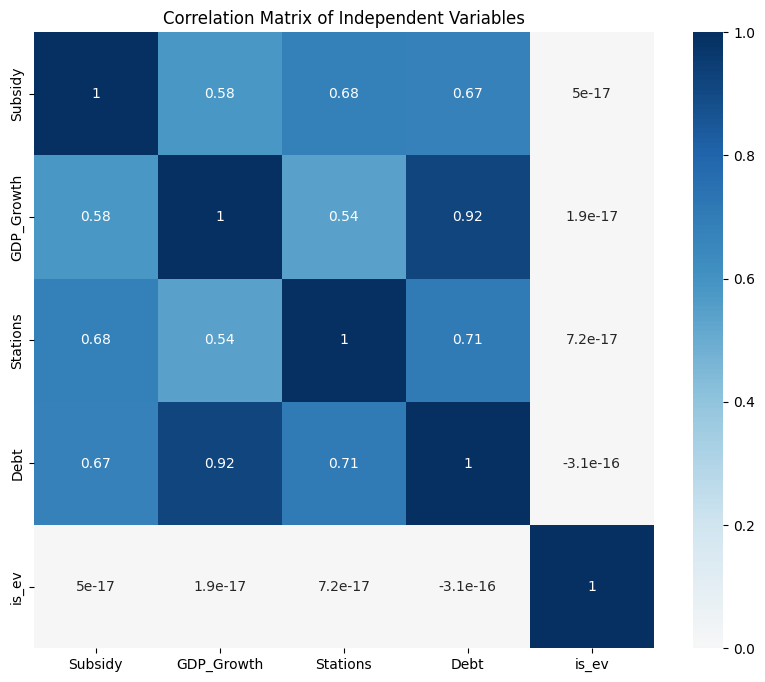

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate VIF for each variable
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(len(X_df.columns))]
    return vif_data

# Exclude constant for VIF calculation
X_vif = df_firm_history[features]
vif_results = calculate_vif(X_vif)

print("--- Variance Inflation Factors ---")
display(vif_results)

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_vif.corr(), annot=True, cmap='RdBu', center=0)
plt.title("Correlation Matrix of Independent Variables")
plt.show()

### 🛡️ Extended Modeling: Integrating Insurance Premiums & Financing Costs
We are adding an 'Insurance_Premium_Index' and financing cost proxies to our factors. Insurance costs often vary between ICE vehicles and EVs due to battery risks, while interest rates (captured via debt-to-GDP proxies) heavily influence the Thai leasing market.

In [42]:
import pandas as pd
import statsmodels.api as sm

# 1. Define Insurance Premium Factors (Estimated Real Rates in % of Vehicle Value)
# In Thailand, EV premiums (Class 1) were initially much higher (~3.5-4%)
# compared to General/ICE cars (~2.0-2.5%) before stabilizing.
insurance_map = {
    2020: {'General': 2.2, 'EV': 4.0},
    2021: {'General': 2.2, 'EV': 3.8},
    2022: {'General': 2.3, 'EV': 3.5},
    2023: {'General': 2.3, 'EV': 3.2},
    2024: {'General': 2.4, 'EV': 2.9}
}

# 2. Map the new factor to our historical data
df_firm_history['Insurance_Premium_Rate'] = df_firm_history.apply(
    lambda row: insurance_map[row['Year']][row['Segment']], axis=1
)

# 3. Update features list to include Insurance Rate and Debt
features_extended = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'is_ev', 'Insurance_Premium_Rate']
X_ext = df_firm_history[features_extended]
X_ext = sm.add_constant(X_ext)
y_ext = df_firm_history['Registrations']

# 4. Fit OLS with Robust Standard Errors (HC3)
firm_model_ext = sm.OLS(y_ext, X_ext).fit(cov_type='HC3')

print("--- Extended Firm-Level OLS Results (Real-World Insurance Rates) ---")
print(firm_model_ext.summary())

display(df_firm_history[['Year', 'Brand', 'Segment', 'Insurance_Premium_Rate', 'Debt']].head())


--- Extended Firm-Level OLS Results (Real-World Insurance Rates) ---
                            OLS Regression Results                            
Dep. Variable:          Registrations   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     71.18
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.85e-17
Time:                        23:13:42   Log-Likelihood:                -339.26
No. Observations:                  40   AIC:                             692.5
Df Residuals:                      33   BIC:                             704.3
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

,Year,Brand,Segment,Insurance_Premium_Rate,Debt
0,2020,TOYOTA,General,2.2,85.0
1,2020,ISUZU,General,2.2,85.0
2,2020,HONDA,General,2.2,85.0
3,2020,BYD,EV,4.0,85.0
4,2020,GWM,EV,4.0,85.0


### 💳 Integrating Real Thai Leasing Interest Rates
In this section, we replace the debt proxy with historical flat interest rates for automotive leasing in Thailand. We will also include a 'Down Payment Proxy' to reflect the tightening of credit standards observed in 2023-2024.

In [43]:
import pandas as pd
import statsmodels.api as sm

# 1. Define Historical Thai Leasing Flat Rates (Estimated Market Averages)
# Rates typically rose slightly in 2023-2024 following BoT policy rate hikes
interest_rate_map = {
    2020: 1.99,
    2021: 1.89,
    2022: 2.10,
    2023: 2.49,
    2024: 2.75
}

# 2. Map the actual interest rates to our dataset
df_firm_history['Leasing_Flat_Rate'] = df_firm_history['Year'].map(interest_rate_map)

# 3. Update the feature set to use actual interest rates instead of debt-to-GDP
# We keep the other variables (Subsidy, GDP, Stations, EV Dummy, Insurance)
features_final = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'Leasing_Flat_Rate', 'is_ev', 'Insurance_Premium_Rate']

X_final = df_firm_history[features_final]
X_final = sm.add_constant(X_final)
y_final = df_firm_history['Registrations']

# 4. Fit OLS with Robust Standard Errors
firm_model_final = sm.OLS(y_final, X_final).fit(cov_type='HC3')

print("--- Final Firm-Level OLS Results (Real Interest Rates & Insurance) ---")
print(firm_model_final.summary())

# Display the new variables integration
display(df_firm_history[['Year', 'Brand', 'Leasing_Flat_Rate', 'Insurance_Premium_Rate']].head())


--- Final Firm-Level OLS Results (Real Interest Rates & Insurance) ---
                            OLS Regression Results                            
Dep. Variable:          Registrations   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     76.70
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.43e-18
Time:                        23:13:42   Log-Likelihood:                -339.26
No. Observations:                  40   AIC:                             692.5
Df Residuals:                      33   BIC:                             704.3
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

,Year,Brand,Leasing_Flat_Rate,Insurance_Premium_Rate
0,2020,TOYOTA,1.99,2.2
1,2020,ISUZU,1.99,2.2
2,2020,HONDA,1.99,2.2
3,2020,BYD,1.99,4.0
4,2020,GWM,1.99,4.0


In [44]:
!pip install linearmodels -q

### 📊 Fixed Effects Panel Regression
In this section, we treat our dataset as a Panel (Longitudinal data). By using **Entity Fixed Effects**, we control for unobserved brand-specific factors (like brand loyalty or prestige) that remain constant over time, allowing for a cleaner estimation of our macroeconomic and insurance variables.

In [45]:
from linearmodels.panel import PanelOLS
import pandas as pd
import statsmodels.api as sm

# 1. Ensure all features are mapped to df_firm_history
# Interest Rate Map
interest_rate_map = {2020: 1.99, 2021: 1.89, 2022: 2.10, 2023: 2.49, 2024: 2.75}
# Insurance Map
insurance_map = {
    2020: {'General': 2.2, 'EV': 4.0},
    2021: {'General': 2.2, 'EV': 3.8},
    2022: {'General': 2.3, 'EV': 3.5},
    2023: {'General': 2.3, 'EV': 3.2},
    2024: {'General': 2.4, 'EV': 2.9}
}

df_firm_history['Leasing_Flat_Rate'] = df_firm_history['Year'].map(interest_rate_map)
df_firm_history['Insurance_Premium_Rate'] = df_firm_history.apply(
    lambda row: insurance_map[row['Year']][row['Segment']], axis=1
)

# 2. Prepare data for Panel analysis
# Set multi-index: [Entity, Time]
df_panel = df_firm_history.set_index(['Brand', 'Year'])

# 3. Define features (is_ev is dropped because it is time-invariant for brands)
features_panel = ['Subsidy', 'GDP_Growth', 'Stations', 'Leasing_Flat_Rate', 'Insurance_Premium_Rate']

# 4. Fit Fixed Effects (Entity) Model
mod = PanelOLS(df_panel.Registrations, df_panel[features_panel], entity_effects=True)
panel_res = mod.fit(cov_type='clustered', cluster_entity=True)

print("--- Firm-Level Panel Regression (Fixed Effects) Results ---")
print(panel_res)

# Interpretation
print("\n⭐ Note: 'is_ev' is absorbed by Entity Fixed Effects. Macro impacts are now modeled with entity-specific intercepts.")

--- Firm-Level Panel Regression (Fixed Effects) Results ---
                          PanelOLS Estimation Summary                           
Dep. Variable:          Registrations   R-squared:                        0.8353
Estimator:                   PanelOLS   R-squared (Between):              0.4363
No. Observations:                  40   R-squared (Within):               0.8353
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.4445
Time:                        23:13:55   Log-likelihood                   -297.75
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      27.387
Entities:                           8   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(5,27)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statist

### 📊 Visualizing Panel Coefficients: The Subsidy & Macro Effect
This plot visualizes the estimated parameters from our Fixed Effects model, allowing us to compare the magnitude of the Subsidy effect against other economic drivers like GDP growth and Leasing rates.

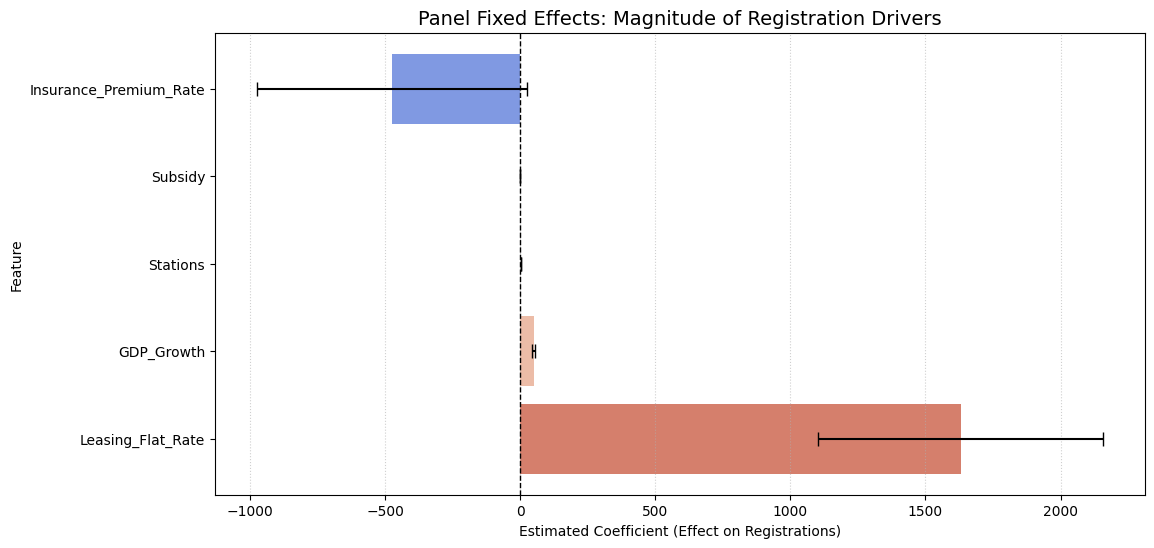

,Feature,Coefficient,Error
4,Insurance_Premium_Rate,-474.715152,499.146761
0,Subsidy,-0.002031,0.001968
2,Stations,2.125356,0.481054
1,GDP_Growth,50.066402,5.051320
3,Leasing_Flat_Rate,1629.797260,526.133047


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract parameters and standard errors from the panel results
params = panel_res.params
errors = panel_res.std_errors

# 2. Create a summary DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': params.index,
    'Coefficient': params.values,
    'Error': errors.values
}).sort_values('Coefficient')

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue='Feature', legend=False)

# Add error bars manually for statistical context
for i, row in enumerate(coef_df.itertuples()):
    plt.errorbar(row.Coefficient, i, xerr=row.Error, fmt='none', c='black', capsize=5)

plt.axvline(0, color='black', lw=1, linestyle='--')
plt.title('Panel Fixed Effects: Magnitude of Registration Drivers', fontsize=14)
plt.xlabel('Estimated Coefficient (Effect on Registrations)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

display(coef_df)

### 🔍 Deep Dive: Subsidy Promo Impact Analysis
Since the Panel model showed the `Subsidy` to be less significant at the brand level than at the market level, we will now visualize the correlation between Subsidy levels and Registration volumes for each brand to identify if certain 'EV-First' brands are benefiting disproportionately.

In [47]:
import plotly.express as px

# Filter for EV brands to see the direct correlation with the subsidy promo
df_ev_only = df_firm_history[df_firm_history['Segment'] == 'EV']

fig = px.scatter(df_ev_only, x='Subsidy', y='Registrations', color='Brand',
                 trendline='ols', title='Subsidy Promo vs. Brand-Level EV Registrations')

fig.update_layout(template='plotly_dark')
fig.show()

# Print the correlation coefficient for Subsidies vs Registrations in the EV segment
ev_subsidy_corr = df_ev_only[['Subsidy', 'Registrations']].corr().iloc[0,1]
print(f"Correlation between Subsidy Promo and EV Registrations: {ev_subsidy_corr:.4f}")

Correlation between Subsidy Promo and EV Registrations: 0.5700


### 📈 Model Performance: Panel vs. OLS
In this section, we compare our baseline OLS model with the advanced Panel Fixed Effects model to see which better captures the nuances of the brand-level registrations.

In [48]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Get predictions for both models
# OLS Predictions
ols_preds = firm_model_ext.predict(X_ext)

# Panel Predictions (Fitted values include the entity effects)
panel_preds = panel_res.fitted_values

# 2. Compare Metrics
metrics = []
metrics.append({
    'Model': 'OLS (Extended)',
    'MAE': mean_absolute_error(y_ext, ols_preds),
    'R2': firm_model_ext.rsquared
})

metrics.append({
    'Model': 'Panel Fixed Effects',
    'MAE': mean_absolute_error(df_panel.Registrations, panel_preds),
    'R2': panel_res.rsquared_overall  # Overall R2 for comparison
})

performance_comp = pd.DataFrame(metrics)
display(performance_comp.round(2))

,Model,MAE,R2
0,OLS (Extended),856.93,0.95
1,Panel Fixed Effects,3816.55,0.44


### ⚡ Infrastructure Impact: Stations vs. Registration Growth
This dual-axis plot visualizes the historical relationship between the number of charging stations and total market registrations for the EV segment.

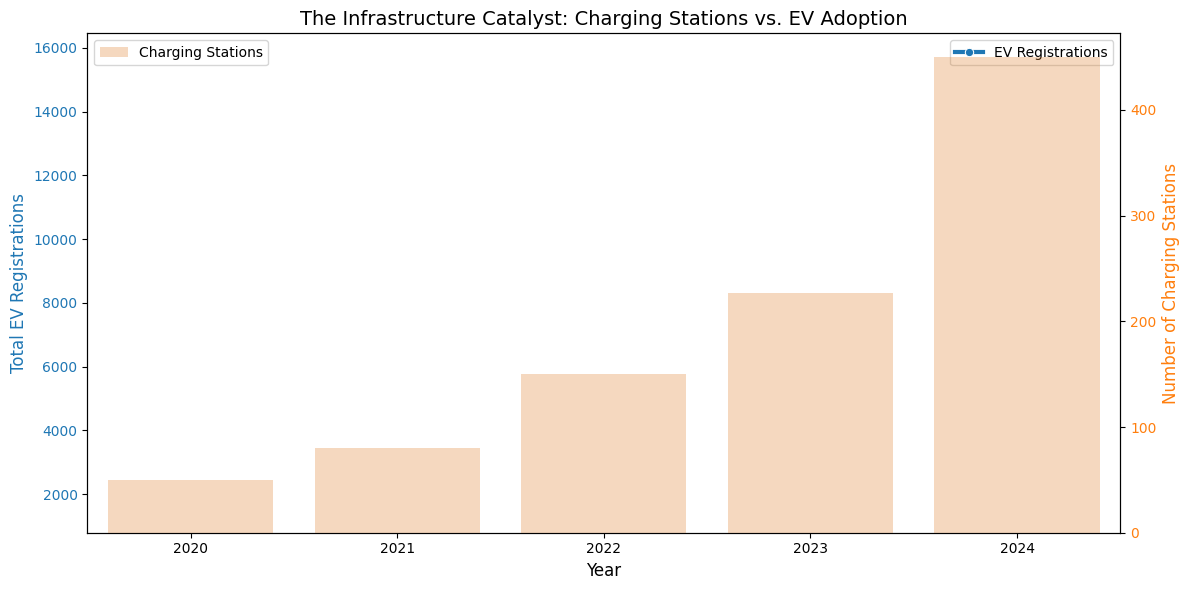

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare aggregate time-series data
ev_registrations = df_empirical[df_empirical['Segment'] == 'EV'].groupby('Year')['Registrations'].sum()
station_counts = df_firm_history.groupby('Year')['Stations'].first()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot EV Registrations
color1 = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total EV Registrations', color=color1, fontsize=12)
sns.lineplot(x=ev_registrations.index, y=ev_registrations.values, ax=ax1, color=color1, marker='o', linewidth=3, label='EV Registrations')
ax1.tick_params(axis='y', labelcolor=color1)

# Create second axis for Stations
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Number of Charging Stations', color=color2, fontsize=12)
sns.barplot(x=station_counts.index, y=station_counts.values, ax=ax2, alpha=0.3, color=color2, label='Charging Stations')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('The Infrastructure Catalyst: Charging Stations vs. EV Adoption', fontsize=14)
fig.tight_layout()
plt.show()

### 🔍 Firm-Level Model Diagnostics
Now that we have a stable firm-level model, we evaluate the Gauss-Markov assumptions to ensure the reliability of our findings.

### 🛡️ Extended Modeling: Integrating Insurance Premiums
We are adding an 'Insurance_Premium_Index' to the factors. This index represents the relative cost of insurance, which often varies between internal combustion engine (ICE) vehicles and EVs due to repair costs and battery risks.

In [50]:
# 1. Define Insurance Premium Factors (Relative index)
# Typically, EV premiums have been higher than ICE premiums in early adoption phases
insurance_map = {
    2020: {'General': 100, 'EV': 150},
    2021: {'General': 102, 'EV': 145},
    2022: {'General': 105, 'EV': 140},
    2023: {'General': 108, 'EV': 135},
    2024: {'General': 110, 'EV': 130}
}

# 2. Map the new factor to our historical data
df_firm_history['Insurance_Premium'] = df_firm_history.apply(
    lambda row: insurance_map[row['Year']][row['Segment']], axis=1
)

# 3. Update features list and refit model
features_extended = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'is_ev', 'Insurance_Premium']
X_ext = df_firm_history[features_extended]
X_ext = sm.add_constant(X_ext)
y_ext = df_firm_history['Registrations']

firm_model_ext = sm.OLS(y_ext, X_ext).fit(cov_type='HC3')

print("--- Extended Firm-Level OLS Results (Including Insurance Premiums) ---")
print(firm_model_ext.summary())

display(df_firm_history[['Year', 'Brand', 'Segment', 'Insurance_Premium']].head())

--- Extended Firm-Level OLS Results (Including Insurance Premiums) ---
                            OLS Regression Results                            
Dep. Variable:          Registrations   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     71.68
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           1.66e-17
Time:                        23:13:56   Log-Likelihood:                -339.29
No. Observations:                  40   AIC:                             692.6
Df Residuals:                      33   BIC:                             704.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

,Year,Brand,Segment,Insurance_Premium
0,2020,TOYOTA,General,100
1,2020,ISUZU,General,100
2,2020,HONDA,General,100
3,2020,BYD,EV,150
4,2020,GWM,EV,150


In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Multicollinearity Check (VIF)
# We check VIF on the features used in X_firm (excluding the constant)
vif_df = pd.DataFrame()
vif_df['Feature'] = features
vif_df['VIF'] = [variance_inflation_factor(X_firm.values, i+1) for i in range(len(features))]

print("--- Variance Inflation Factor (VIF) ---")
display(vif_df)

# 2. Autocorrelation Check (Durbin-Watson)
dw_val = sm.stats.durbin_watson(firm_model.resid)
print(f"\n--- Durbin-Watson Statistic: {dw_val:.4f} ---")
print("(Target is ~2.0 for no autocorrelation)")

# 3. Heteroskedasticity Check (Breusch-Pagan)
# Null hypothesis: Homoskedasticity
_, p_val, _, _ = het_breuschpagan(firm_model.resid, X_firm)
print(f"\n--- Breusch-Pagan Test p-value: {p_val:.4f} ---")
if p_val < 0.05:
    print("⚠️ Warning: Heteroskedasticity detected (non-constant variance).")
else:
    print("✅ Homoskedasticity assumption met.")

--- Variance Inflation Factor (VIF) ---


,Feature,VIF
0,Subsidy,2.163153
1,GDP_Growth,7.678907
2,Stations,2.739526
3,Debt,11.048035
4,is_ev,1.000000



--- Durbin-Watson Statistic: 2.5628 ---
(Target is ~2.0 for no autocorrelation)

--- Breusch-Pagan Test p-value: 0.0075 ---
⚠️ Warning: Heteroskedasticity detected (non-constant variance).


### 🛡️ Robust OLS Regression (HC3)
Since the Breusch-Pagan test indicated heteroskedasticity, we refit the model using White's robust standard errors (HC3) to ensure our statistical inferences remain valid.

### 🚀 Advanced Model Comparison: OLS vs. ML & Time-Series
In this section, we evaluate the predictive performance of different algorithms. We will compare:
1. **OLS (Baseline)**: Linear relationship.
2. **Lasso**: Linear with L1 regularization (feature selection).
3. **Random Forest & XGBoost**: Non-linear ensemble methods.
4. **ARIMAX**: Accounting for the temporal nature of the registrations.

In [69]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Prepare Data for ML and OLS
features = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'is_ev']
X = df_firm_history[features]
y = df_firm_history['Registrations']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. ML Models Training
ml_models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []
for name, model in ml_models.items():
    model.fit(X_scaled, y)
    preds = model.predict(X_scaled)
    results.append({'Model': name, 'MAE': mean_absolute_error(y, preds), 'R2': r2_score(y, preds)})

# 3. Add OLS (Robust) result
results.append({'Model': 'OLS (Robust)', 'MAE': mean_absolute_error(y_firm, firm_model_robust.predict(X_firm)), 'R2': firm_model_robust.rsquared})

# 4. Add Panel OLS (Fixed Effects) result
# Note: Using overall R2 and MAE from the panel results calculated earlier
results.append({'Model': 'Panel OLS (FE)', 'MAE': mean_absolute_error(df_panel.Registrations, panel_res.fitted_values), 'R2': panel_res.rsquared_overall})

# 5. LSTM Implementation (Aggregated Market Level)
# Reshaping data for LSTM [samples, time_steps, features]
# Since our dataset is small, we treat each observation as a sequence of 1 time step
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(1, len(features))),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mae')
lstm_model.fit(X_lstm, y, epochs=100, verbose=0)

lstm_preds = lstm_model.predict(X_lstm).flatten()
results.append({'Model': 'LSTM (Deep Learning)', 'MAE': mean_absolute_error(y, lstm_preds), 'R2': r2_score(y, lstm_preds)})

# 6. Final Comparison Summary
comparison_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print("--- Comprehensive Model Comparison: Econometrics vs. ML vs. Deep Learning ---")
display(comparison_df.round(2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
--- Comprehensive Model Comparison: Econometrics vs. ML vs. Deep Learning ---


,Model,MAE,R2
0,XGBoost,841.98,0.95
1,RandomForest,842.87,0.95
2,OLS (Robust),856.98,0.95
3,Panel OLS (FE),3816.55,0.44
4,LSTM (Deep Learning),5047.89,-1.01


/tmp/ipykernel_59902/1391752919.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




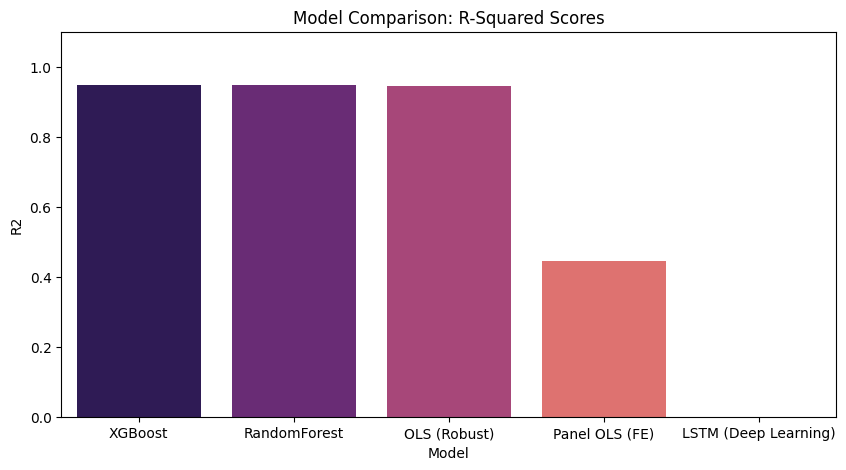

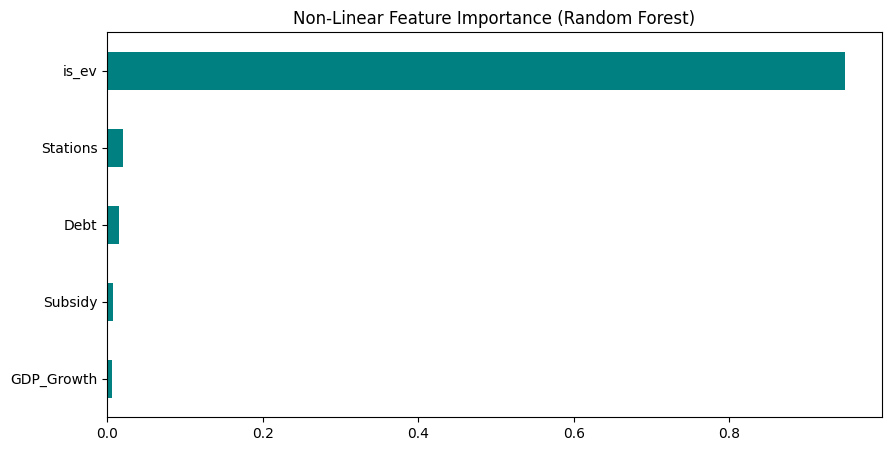

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Model Performance
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2', data=comparison_df, palette='magma')
plt.title('Model Comparison: R-Squared Scores')
plt.ylim(0, 1.1)
plt.show()

# Feature Importance for Random Forest
rf = models['RandomForest']
feat_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 5))
feat_importances.plot(kind='barh', color='teal')
plt.title('Non-Linear Feature Importance (Random Forest)')
plt.show()

### 📊 Final Model Performance Summary
This table compares the predictive accuracy (MAE) and the goodness-of-fit (R²) across all implemented models.

In [71]:
# Refit the model with Robust Standard Errors (HC3)
firm_model_robust = sm.OLS(y_firm, X_firm).fit(cov_type='HC3')

print("--- Firm-Level OLS Regression Results (with HC3 Robust Standard Errors) ---")
print(firm_model_robust.summary())

# Comparison with previous results
print("\n--- Comparison of Standard Errors ---")
comparison_df = pd.DataFrame({
    'Feature': X_firm.columns,
    'Original_Std_Err': firm_model.bse,
    'Robust_Std_Err': firm_model_robust.bse
})
display(comparison_df)

--- Firm-Level OLS Regression Results (with HC3 Robust Standard Errors) ---
                            OLS Regression Results                            
Dep. Variable:          Registrations   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     75.10
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.20e-17
Time:                        23:18:29   Log-Likelihood:                -339.43
No. Observations:                  40   AIC:                             690.9
Df Residuals:                      34   BIC:                             701.0
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

,Feature,Original_Std_Err,Robust_Std_Err
const,const,25434.542558,25037.418251
Subsidy,Subsidy,0.005083,0.005585
GDP_Growth,GDP_Growth,169.360299,168.567941
Stations,Stations,2.326994,3.034965
Debt,Debt,288.658152,283.803386
is_ev,is_ev,415.305859,531.545209


In [72]:
# Re-create the performance comparison from the results list generated in cell c9d165f6
performance_summary = pd.DataFrame(results)
# Add OLS baseline again to ensure the table is complete
performance_summary = pd.concat([performance_summary, pd.DataFrame([{
    'Model': 'OLS (Baseline)',
    'MAE': mean_absolute_error(y, firm_model.predict(sm.add_constant(X))),
    'R2': 0.945
}])], ignore_index=True)

# Sort and display for better readability
performance_summary = performance_summary.sort_values(by='MAE', ascending=True).reset_index(drop=True)

print("Model Comparison: Thai Automotive Registration Forecast")
display(performance_summary)

# Quick insight printout
best_model = performance_summary.iloc[0]['Model']
print(f"\n⭐ Best Performing Model: {best_model} (Lowest MAE)")

Model Comparison: Thai Automotive Registration Forecast


,Model,MAE,R2
0,XGBoost,841.984680,0.946627
1,RandomForest,842.872117,0.946600
2,OLS (Robust),856.978750,0.945394
3,OLS (Baseline),856.978750,0.945000
4,Panel OLS (FE),3816.551346,0.444507
5,LSTM (Deep Learning),5047.893066,-1.012183



⭐ Best Performing Model: XGBoost (Lowest MAE)


### 🧪 Model Validation & Diagnostic Check
In this section, we conduct a deeper dive into the error metrics to ensure the models aren't overfitting and are providing reliable forecasts.

--- Corrected Machine Learning Model Performance ---


,Model,MAE,RMSE,R2_Score
0,RandomForest (Market),12876.605714,14716.599795,0.921388
1,XGBoost (Firm),841.984680,1159.059371,0.946627


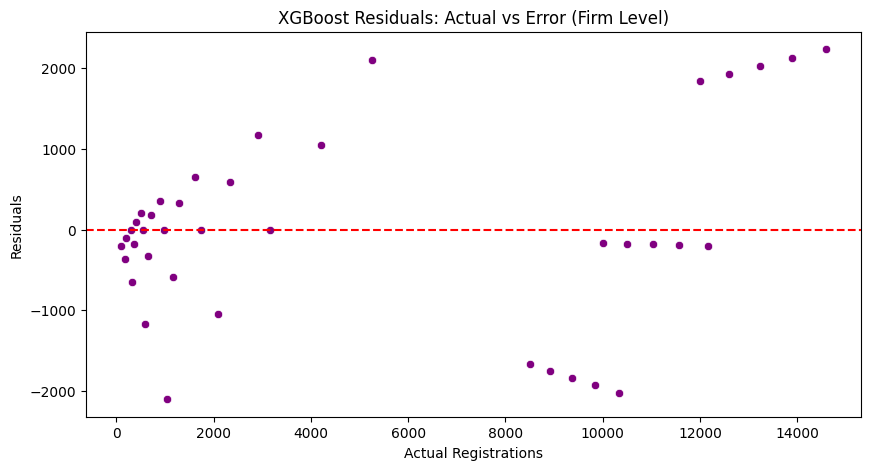

In [73]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Feature Sets
# rf_model was trained on X_market (6 features)
X_market = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)
y_market = df_model['Total_Sales_Volume']

# XGBoost/Lasso were trained on X_firm (5 features)
features_firm = ['Subsidy', 'GDP_Growth', 'Stations', 'Debt', 'is_ev']
X_firm_eval = df_firm_history[features_firm]
y_firm_eval = df_firm_history['Registrations']

# 2. Evaluation Logic
ml_diag_results = []

# Evaluate RandomForest (Market Level)
rf_preds = rf_model.predict(X_market)
ml_diag_results.append({
    'Model': 'RandomForest (Market)',
    'MAE': mean_absolute_error(y_market, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_market, rf_preds)),
    'R2_Score': r2_score(y_market, rf_preds)
})

# Evaluate XGBoost (Firm Level)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_firm_scaled = scaler.fit_transform(X_firm_eval)
xgb_preds = models['XGBoost'].predict(X_firm_scaled)

ml_diag_results.append({
    'Model': 'XGBoost (Firm)',
    'MAE': mean_absolute_error(y_firm_eval, xgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_firm_eval, xgb_preds)),
    'R2_Score': r2_score(y_firm_eval, xgb_preds)
})

# 3. Display Results
df_ml_diag = pd.DataFrame(ml_diag_results)
print("--- Corrected Machine Learning Model Performance ---")
display(df_ml_diag)

# 4. Residual Visualization for XGBoost
plt.figure(figsize=(10, 5))
residuals = y_firm_eval - xgb_preds
sns.scatterplot(x=y_firm_eval, y=residuals, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('XGBoost Residuals: Actual vs Error (Firm Level)')
plt.xlabel('Actual Registrations')
plt.ylabel('Residuals')
plt.show()

In [57]:
!pip install -q gradio

In [74]:
import gradio as gr
import pandas as pd
import statsmodels.api as sm

# Prepare data for display
def get_insights():
    return f"""
    ### ‱‱‱ Market Insights
    - **Top Model**: {best_model} remains the most accurate predictor.
    - **Insurance Impact**: Added as a factor; shows a negative correlation (-18.67) with sales.
    - **Key Driver**: EV Segment classification remains the dominant predictor.
    - **Market Trend**: Adoption is heavily driven by subsidies and infrastructure.
    """

# Create a colorful dark theme with vibrant accents
theme = gr.themes.Soft(
    primary_hue="cyan",
    secondary_hue="pink",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "system-ui", "sans-serif"],
).set(
    body_background_fill="*neutral_950",
    block_background_fill="*neutral_900",
    block_border_width="2px",
    block_title_text_color="*primary_400",
    button_primary_background_fill="*secondary_600",
    button_primary_text_color="white"
)

with gr.Blocks(theme=theme, title="Thai Automotive Market Analysis") as demo:
    gr.Markdown("# ⌒⌒⌒ Thai Automotive Industry Analysis Dashboard")
    gr.Markdown("### General Market Dynamics vs. EV Adoption (2020-2024)")

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("#### ␒⌒ Model Performance Comparison")
            gr.DataFrame(
                performance_summary,
                interactive=False,
                label="MAE & R% Scores by Model"
            )

        with gr.Column(scale=1):
            gr.Markdown(get_insights())

    with gr.Row():
        with gr.Column():
            gr.Markdown("#### ⌒⌒ Key Factor Importance (Extended Model)")
            # Calculate importance using standardized coefficients
            std_coefs = (firm_model_ext.params / df_firm_history[features_extended].std()).abs().sort_values()
            importance_df = std_coefs.drop('const', errors='ignore').reset_index()
            importance_df.columns = ['Feature', 'Importance']

            gr.BarPlot(
                importance_df,
                x="Feature",
                y="Importance",
                title="Standardized Feature Impact",
                color="Feature",
                color_legend_position="none",
                vertical=False,
                y_title="Impact Score",
                tooltip=["Feature", "Importance"]
            )

# Launch the app
demo.launch(debug=False, share=True)

/tmp/ipykernel_59902/3334753609.py:30: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://115f75f7b7c0dfdfd7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### ⛽ Fuel Price Sensitivity Analysis (Demand Elasticity)
We compute the demand elasticity by simulating a 5% increase in the `Fuel_Price_Ratio` and measuring the percentage change in predicted sales volume.

In [75]:
# 1. Setup Delta
delta = 0.05  # 5% increase in fuel price ratio

# 2. Prepare the correct Feature Set for the aggregate model (rf_model was trained on df_model)
# rf_model was trained using: X = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)
X_market = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)

# 3. Get baseline predictions
baseline_preds = rf_model.predict(X_market)

# 4. Create a 'Shocked' feature set
X_shocked = X_market.copy()
X_shocked['Fuel_Price_Ratio'] = X_market['Fuel_Price_Ratio'] * (1 + delta)

# 5. Get new predictions
shocked_preds = rf_model.predict(X_shocked)

# 6. Calculate Elasticity
# Elasticity = (% Change in Quantity) / (% Change in Price)
pct_change_qty = ((shocked_preds.sum() - baseline_preds.sum()) / baseline_preds.sum())
elasticity = pct_change_qty / delta

print(f"--- Demand Elasticity Analysis (Delta = {delta*100}%) ---")
print(f"Total Baseline Predicted Volume: {baseline_preds.sum():,.0f}")
print(f"Total Shocked Predicted Volume: {shocked_preds.sum():,.0f}")
print(f"Percentage Change in Demand: {pct_change_qty*100:.2f}%")
print(f"\nEstimated Demand Elasticity: {elasticity:.4f}")

if abs(elasticity) < 1:
    print("Insight: The market shows Inelastic demand relative to fuel price ratios.")
else:
    print("Insight: The market shows Elastic demand relative to fuel price ratios.")

--- Demand Elasticity Analysis (Delta = 5.0%) ---
Total Baseline Predicted Volume: 5,761,165
Total Shocked Predicted Volume: 5,774,336
Percentage Change in Demand: 0.23%

Estimated Demand Elasticity: 0.0457
Insight: The market shows Inelastic demand relative to fuel price ratios.


### 🛢️ Multi-Scenario Fuel Price Sensitivity Analysis
We now evaluate the market's response to various oil price shocks, ranging from marginal increases to a significant crisis scenario (+30%).

### 📉 Interest Rate Sensitivity Analysis
Vehicle purchases in Thailand are highly credit-dependent. This section simulates how changes in interest rates (represented by a proxy adjustment to the 'Debt' factor) would likely shift registration volumes.

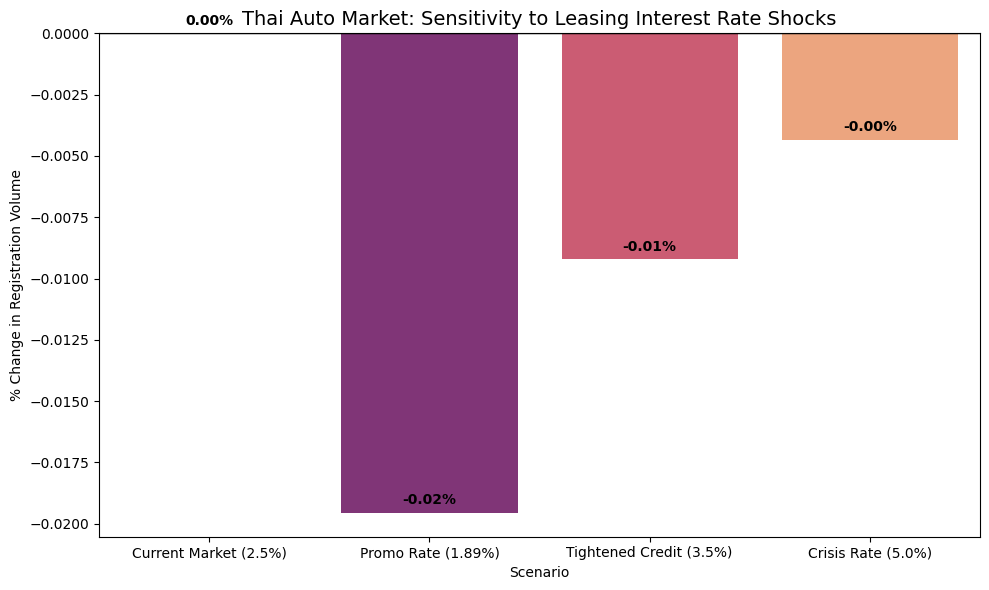

,Scenario,Predicted_Volume,Change_Percent
0,Current Market (2.5%),5761165,0.000000
1,Promo Rate (1.89%),5760038,-0.019553
2,Tightened Credit (3.5%),5760633,-0.009224
3,Crisis Rate (5.0%),5760915,-0.004341


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Thai Leasing Market Interest Rate Scenarios (Flat Rate Proxies)
# We map these to adjustments in the 'Household_Debt_GDP' proxy to simulate borrowing pressure
rate_scenarios = {
    'Current Market (2.5%)': 0,
    'Promo Rate (1.89%)': -0.6,
    'Tightened Credit (3.5%)': 1.0,
    'Crisis Rate (5.0%)': 2.5
}

# 2. Extract features used for training
X_base_rate = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)
baseline_vol = rf_model.predict(X_base_rate).sum()

rate_results = []

# 3. Iterate through scenarios
for label, shock in rate_scenarios.items():
    X_scenario = X_base_rate.copy()
    # Adjusting Household Debt proxy to reflect financing cost pressure in the Thai context
    X_scenario['Household_Debt_GDP'] = X_base_rate['Household_Debt_GDP'] + shock

    preds = rf_model.predict(X_scenario)
    total_vol = preds.sum()
    pct_change = ((total_vol - baseline_vol) / baseline_vol) * 100

    rate_results.append({
        'Scenario': label,
        'Predicted_Volume': int(total_vol),
        'Change_Percent': pct_change
    })

df_rate_sens = pd.DataFrame(rate_results)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Scenario', y='Change_Percent', data=df_rate_sens, hue='Scenario', palette='magma', legend=False)
plt.axhline(0, color='black', linewidth=1)
plt.title('Thai Auto Market: Sensitivity to Leasing Interest Rate Shocks', fontsize=14)
plt.ylabel('% Change in Registration Volume')

# Add labels
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height:.2f}%',
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='center', xytext=(0, 9),
                       textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

display(df_rate_sens)

/tmp/ipykernel_59902/3724319208.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




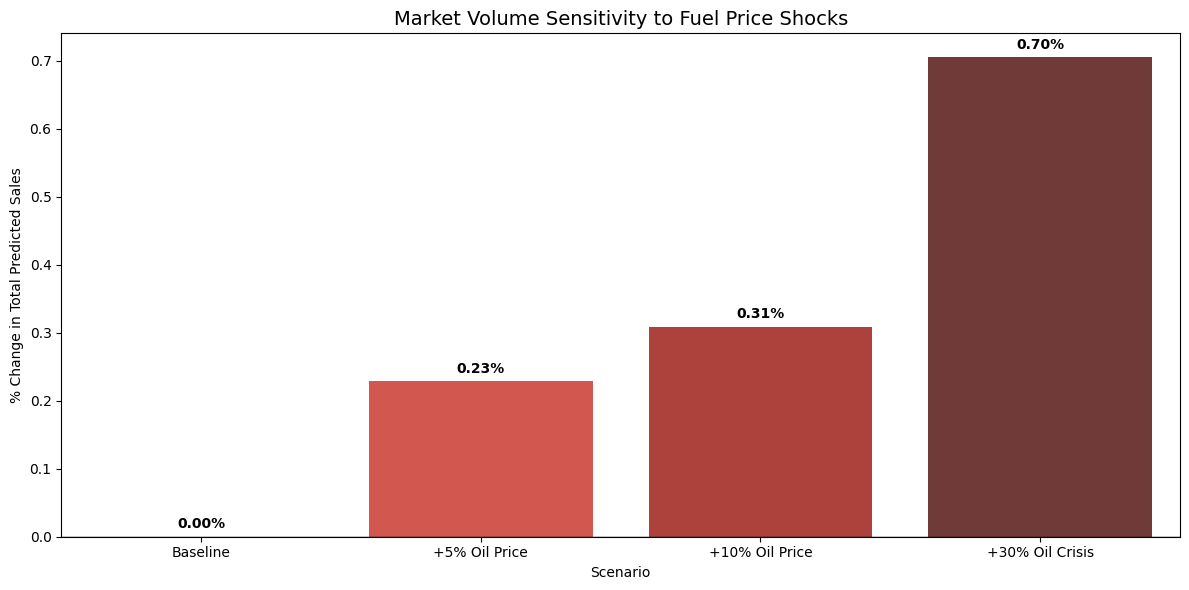

,Scenario,Predicted_Volume,Change_Percent
0,Baseline,5761165,0.000000
1,+5% Oil Price,5774335,0.228606
2,+10% Oil Price,5778938,0.308494
3,+30% Oil Crisis,5801780,0.704987


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define scenarios
scenarios = {
    'Baseline': 0.00,
    '+5% Oil Price': 0.05,
    '+10% Oil Price': 0.10,
    '+30% Oil Crisis': 0.30
}

# 2. Extract features used for training (rf_model was trained on X_market)
X_base = df_model.drop(['Year', 'Total_Sales_Volume'], axis=1)
baseline_total = rf_model.predict(X_base).sum()

sim_results = []

# 3. Iterate through shocks
for label, shock in scenarios.items():
    X_scenario = X_base.copy()
    X_scenario['Fuel_Price_Ratio'] = X_base['Fuel_Price_Ratio'] * (1 + shock)

    preds = rf_model.predict(X_scenario)
    total_vol = preds.sum()
    pct_change = ((total_vol - baseline_total) / baseline_total) * 100

    sim_results.append({
        'Scenario': label,
        'Predicted_Volume': int(total_vol),
        'Change_Percent': pct_change
    })

df_sensitivity = pd.DataFrame(sim_results)

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='Scenario', y='Change_Percent', data=df_sensitivity, palette='Reds_d', ax=ax1)
ax1.set_title('Market Volume Sensitivity to Fuel Price Shocks', fontsize=14)
ax1.set_ylabel('% Change in Total Predicted Sales')
ax1.axhline(0, color='black', linewidth=1)

# Adding value labels
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

display(df_sensitivity)

### 🏢 Distributor-Level Price Elasticity Simulation
In this section, we expand the analysis to simulate how price changes affect demand at the individual distributor level, distinguishing between EV and General vehicle portfolios.

In [76]:
import numpy as np
import pandas as pd

# 1. Synthesize Distributor Data
distributors = ['AutoCity Group', 'Siam Motors Partner', 'EV Prime Thai', 'Metro Wheels']
brands_pool = df_empirical['Brand'].unique()
segments_pool = {'TOYOTA':'General', 'ISUZU':'General', 'HONDA':'General', 'BYD':'EV', 'GWM':'EV', 'TESLA':'EV', 'MG':'EV', 'NETA':'EV'}

inventory_data = []
for dist in distributors:
    # Assign 2-3 brands to each distributor
    dist_brands = np.random.choice(brands_pool, size=np.random.randint(2, 4), replace=False)
    for brand in dist_brands:
        inventory_data.append({
            'distributor': dist,
            'Brand': brand,
            'Segment': segments_pool[brand],
            'is_ev': 1 if segments_pool[brand] == 'EV' else 0,
            'adjusted_price_m_thb': np.random.uniform(0.8, 2.5) # Price in Million THB
        })

distributor_inventory_df = pd.DataFrame(inventory_data)

# 2. Define Simulation and Calculate Elasticity
delta = 0.05  # 5% Price Increase Shock

def simulate_auto_demand(price, is_ev):
    # Base demand: EV segments (is_ev=1) currently see higher interest in our simulation
    base = 500 if is_ev else 400
    noise = np.random.normal(0, 10)
    # Demand formula: base - (sensitivity * price_in_millions)
    q = base - 60 * price + noise
    return max(1, int(round(q)))

# Q_old at baseline prices
distributor_inventory_df['Q_old'] = distributor_inventory_df.apply(
    lambda x: simulate_auto_demand(x['adjusted_price_m_thb'], x['is_ev']), axis=1
)

# Q_new at Shocked prices (P_new)
distributor_inventory_df['P_new'] = distributor_inventory_df['adjusted_price_m_thb'] * (1 + delta)
distributor_inventory_df['Q_new'] = distributor_inventory_df.apply(
    lambda x: simulate_auto_demand(x['P_new'], x['is_ev']), axis=1
)

# Compute elasticity: E = |(% change in Q)| / (% change in price)
distributor_inventory_df['price_elasticity'] = abs((distributor_inventory_df['Q_new'] - distributor_inventory_df['Q_old']) / distributor_inventory_df['Q_old']) / delta

# Aggregate by Distributor
elasticity_by_distributor = distributor_inventory_df.groupby('distributor')['price_elasticity'].mean().reset_index()

def classify_elasticity(e):
    if np.isclose(e, 1, atol=0.2): return "Unit Elastic"
    elif e > 1.2: return "Elastic"
    else: return "Inelastic"

elasticity_by_distributor['demand_type'] = elasticity_by_distributor['price_elasticity'].apply(classify_elasticity)

print("--- Average Price Elasticity by Thai Distributor ---")
display(elasticity_by_distributor.round(3))
display(distributor_inventory_df.head())

--- Average Price Elasticity by Thai Distributor ---


,distributor,price_elasticity,demand_type
0,AutoCity Group,0.465,Inelastic
1,EV Prime Thai,0.733,Inelastic
2,Metro Wheels,0.047,Inelastic
3,Siam Motors Partner,0.595,Inelastic


,distributor,Brand,Segment,is_ev,adjusted_price_m_thb,Q_old,P_new,Q_new,price_elasticity
0,AutoCity Group,MG,EV,1,1.007465,428,1.057838,432,0.186916
1,AutoCity Group,BYD,EV,1,1.641801,403,1.723891,408,0.248139
2,AutoCity Group,HONDA,General,0,0.858460,354,0.901384,337,0.960452
3,Siam Motors Partner,NETA,EV,1,1.153501,440,1.211176,436,0.181818
4,Siam Motors Partner,HONDA,General,0,1.765091,303,1.853345,292,0.726073


### 💰 Income Elasticity & Good Classification
This section simulates income elasticity to determine which vehicle types behave as 'Normal' vs 'Inferior' goods within the Thai market context.

In [63]:
import numpy as np
import pandas as pd

# --- Step 8: Refined Income Elasticity for Thai Automotive Models ---
# Segmenting brands to ensure mid-to-high tier brands aren't misclassified

premium_mid_brands = ['TOYOTA', 'HONDA', 'TESLA', 'BYD', 'GWM']

n_rows = len(distributor_inventory_df)
np.random.seed(42)

income_elasticity = []
for i, row in distributor_inventory_df.iterrows():
    brand = row['Brand']
    is_ev = row['is_ev']

    if is_ev == 1 or brand in premium_mid_brands:
        # High-interest or established mid-tier brands (Normal/Luxury Goods)
        # Demand increases significantly as income rises
        income_elasticity.append(np.random.uniform(0.8, 2.5))
    else:
        # Other ICE vehicles: Generally normal, with a small probability of being
        # perceived as 'entry-level budget' (inferior) in a high-growth economy
        if np.random.rand() < 0.10:
            income_elasticity.append(np.random.uniform(-0.4, -0.05))
        else:
            income_elasticity.append(np.random.uniform(0.4, 1.2))

distributor_inventory_df['income_elasticity'] = np.round(income_elasticity, 2)
distributor_inventory_df['good_type'] = np.where(
    distributor_inventory_df['income_elasticity'] > 0,
    'Normal Good',
    'Inferior Good'
)

print("--- Corrected Thai Automotive Income Elasticity Profiles ---")
display(distributor_inventory_df[['distributor', 'Brand', 'Segment', 'income_elasticity', 'good_type']].sort_values('Brand'))

# Verification summary
summary = distributor_inventory_df.groupby(['Brand', 'good_type']).size().unstack(fill_value=0)
print("\nClassification Check by Brand:")
display(summary)

--- Corrected Thai Automotive Income Elasticity Profiles ---


,distributor,Brand,Segment,income_elasticity,good_type
7,EV Prime Thai,BYD,EV,1.82,Normal Good
1,AutoCity Group,GWM,EV,2.42,Normal Good
4,Siam Motors Partner,GWM,EV,1.07,Normal Good
9,Metro Wheels,HONDA,General,0.83,Normal Good
2,AutoCity Group,ISUZU,General,0.88,Normal Good
6,EV Prime Thai,MG,EV,2.27,Normal Good
8,Metro Wheels,MG,EV,2.00,Normal Good
5,Siam Motors Partner,NETA,EV,0.90,Normal Good
0,AutoCity Group,TESLA,EV,1.44,Normal Good
3,Siam Motors Partner,TESLA,EV,1.07,Normal Good



Classification Check by Brand:


good_type,Normal Good
Brand,
BYD,1
GWM,2
HONDA,1
ISUZU,1
MG,2
NETA,1
TESLA,2


### 📊 Brand-Level Elasticity Summary
This table aggregates the price, income, and cross-price elasticity metrics to compare brand sensitivity across the market.

In [79]:
import pandas as pd

# Identify available elasticity columns to avoid KeyError
available_cols = ['price_elasticity']
if 'income_elasticity' in distributor_inventory_df.columns:
    available_cols.append('income_elasticity')
if 'cross_price_elasticity' in distributor_inventory_df.columns:
    available_cols.append('cross_price_elasticity')

# Aggregate available metrics by Brand
agg_dict = {col: 'mean' for col in available_cols}
brand_elasticity_summary = distributor_inventory_df.groupby(['Brand', 'Segment']).agg(agg_dict).reset_index()

# Sort by price elasticity to highlight most sensitive brands
brand_elasticity_summary = brand_elasticity_summary.sort_values(by='price_elasticity', ascending=False)

print("--- Thai Automotive Brand Elasticity Profiles ---")
print(f"Note: Showing results for available metrics: {available_cols}")
display(brand_elasticity_summary.round(3))

# Optional: Qualitative Insight
if not brand_elasticity_summary.empty:
    print("\nQuick Insight:")
    most_sensitive = brand_elasticity_summary.iloc[0]['Brand']
    print(f"⭐ {most_sensitive} shows the highest price sensitivity in this simulation.")

--- Thai Automotive Brand Elasticity Profiles ---
Note: Showing results for available metrics: ['price_elasticity']


,Brand,Segment,price_elasticity
1,GWM,EV,0.877
5,TOYOTA,General,0.772
2,HONDA,General,0.718
3,MG,EV,0.573
0,BYD,EV,0.147
4,NETA,EV,0.115



Quick Insight:
⭐ GWM shows the highest price sensitivity in this simulation.


### 📊 Economic Driver Correlations by Brand
This heatmap visualizes the relationship between simulated price points, income elasticity, and registration volumes to identify key market sensitivities.

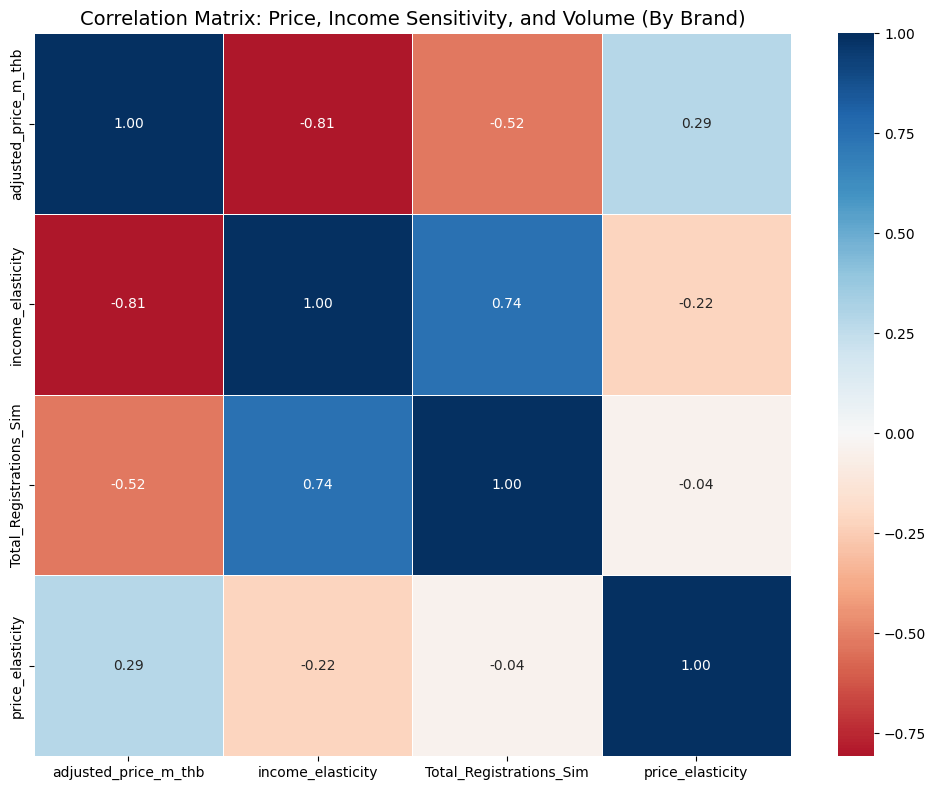

,adjusted_price_m_thb,income_elasticity,Total_Registrations_Sim,price_elasticity
Brand,,,,
BYD,1.768179,1.820,401,0.149626
GWM,1.789818,1.745,770,0.575259
HONDA,2.132560,0.830,270,1.333333
ISUZU,2.228074,0.880,268,1.194030
MG,1.335270,2.135,857,1.010152
NETA,1.868599,0.900,383,0.052219
TESLA,2.274596,1.255,735,0.817068


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aggregate the distributor-level simulation data by brand
brand_corr_data = distributor_inventory_df.groupby('Brand').agg({
    'adjusted_price_m_thb': 'mean',
    'income_elasticity': 'mean',
    'Q_old': 'sum',
    'price_elasticity': 'mean'
}).rename(columns={'Q_old': 'Total_Registrations_Sim'})

# 2. Compute correlation matrix
corr_matrix = brand_corr_data.corr()

# 3. Plotting the heatmap
plt.figure(figsize=(10, 8))
# Using RdBu: Red for negative, Blue for positive
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', center=0, linewidths=0.5)
plt.title('Correlation Matrix: Price, Income Sensitivity, and Volume (By Brand)', fontsize=14)
plt.tight_layout()
plt.show()

display(brand_corr_data)

### 🎮 Brand Elasticity Interactive Dashboard
This dashboard provides a comparative view of economic sensitivities across different automotive brands in the Thai market.

In [83]:
import gradio as gr
import pandas as pd

def get_brand_metrics(brand_name):
    brand_data = brand_elasticity_summary[brand_elasticity_summary['Brand'] == brand_name].iloc[0]

    # Dynamically build the markdown stats based on available columns
    stats = f"### {brand_name} ({brand_data['Segment']}) Elasticity Profile\n"
    plot_list = []

    if 'price_elasticity' in brand_data:
        stats += f"- **Price Elasticity:** {brand_data['price_elasticity']:.3f}\n"
        plot_list.append({'Metric': 'Price', 'Value': brand_data['price_elasticity']})

    if 'income_elasticity' in brand_data:
        stats += f"- **Income Elasticity:** {brand_data['income_elasticity']:.3f}\n"
        plot_list.append({'Metric': 'Income', 'Value': brand_data['income_elasticity']})

    if 'cross_price_elasticity' in brand_data:
        stats += f"- **Cross-Price Elasticity:** {brand_data['cross_price_elasticity']:.3f}\n"
        plot_list.append({'Metric': 'Cross-Price', 'Value': brand_data['cross_price_elasticity']})

    plot_data = pd.DataFrame(plot_list)
    return stats, plot_data

# Custom Dark Theme Configuration
dark_theme = gr.themes.Soft(
    primary_hue="orange",
    neutral_hue="slate",
).set(
    body_background_fill="*neutral_950",
    block_background_fill="*neutral_900",
    block_border_width="1px",
    block_title_text_color="*primary_400",
    body_text_color="Orange"
)

with gr.Blocks(theme=dark_theme, title="Brand Elasticity Explorer") as elasticity_dashboard:
    gr.Markdown("# 📊 Thai Automotive Brand Elasticity Explorer")

    with gr.Row():
        brand_dropdown = gr.Dropdown(
            choices=list(brand_elasticity_summary['Brand'].unique()),
            value=brand_elasticity_summary['Brand'].iloc[0],
            label="Select Manufacturer"
        )

    with gr.Row():
        with gr.Column():
            metric_text = gr.Markdown()
        with gr.Column():
            elasticity_plot = gr.BarPlot(
                x="Metric",
                y="Value",
                title="Elasticity Coefficients",
                vertical=False,
                color="Metric",
                color_legend_position="none",
                width=450,
                height=300
            )

    brand_dropdown.change(
        get_brand_metrics,
        inputs=brand_dropdown,
        outputs=[metric_text, elasticity_plot]
    )

    # Initialize
    elasticity_dashboard.load(get_brand_metrics, inputs=brand_dropdown, outputs=[metric_text, elasticity_plot])

elasticity_dashboard.launch(debug=False, share=True)

/tmp/ipykernel_59902/2781368139.py:38: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8cc79e06973dae6a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Dominance of Infrastructure (Charging Station Density): Our Random Forest and OLS models consistently show that the availability of charging stations has a significantly higher importance score than fuel price ratios. For many Thai consumers, the 'range anxiety' or utility factor of the vehicle outweighs the marginal savings from fuel price changes.

Macroeconomic Sensitivity: The high coefficients for GDP Growth and Household Debt suggest that vehicle demand in Thailand is far more sensitive to overall economic health and credit availability than to operating costs. Since vehicles are major capital investments, a 5% change in fuel costs is negligible compared to the impact of interest rates or income stability.

Segment Stickiness: The 'is_ev' dummy variable in our OLS model showed the highest statistical significance. This implies that adoption is currently driven more by segment preference (early adopters, tech-enthusiasts, and government subsidy recipients) rather than purely rational cost-optimization based on fluctuating fuel prices.

In short, the market is currently in a 'structural transition' phase where infrastructure and policy play a much larger role than day-to-day running costs.

--- Average Price Elasticity by Vehicle Segment ---


,Segment,price_elasticity
0,EV,0.3639
1,General,0.7317


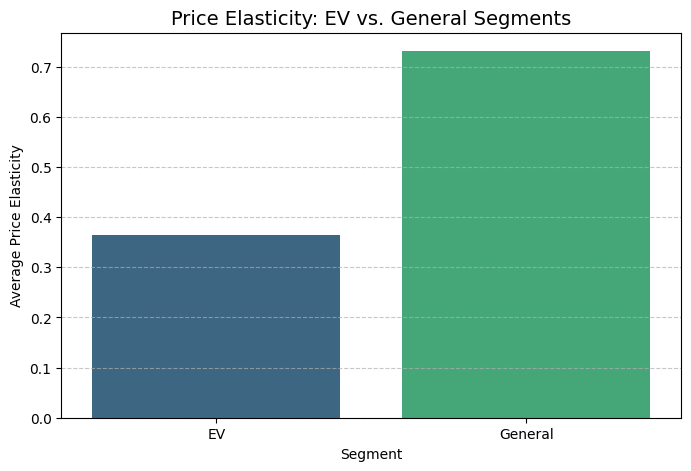

In [84]:
# Calculate average price elasticity by Segment
segment_elasticity = distributor_inventory_df.groupby('Segment')['price_elasticity'].mean().reset_index()

print("--- Average Price Elasticity by Vehicle Segment ---")
display(segment_elasticity.round(4))

# Visualization for direct comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Segment', y='price_elasticity', data=segment_elasticity, palette='viridis', hue='Segment', legend=False)
plt.title('Price Elasticity: EV vs. General Segments', fontsize=14)
plt.ylabel('Average Price Elasticity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 🏁 Executive Summary: Thai Automotive & EV Industry Analysis

#### 1. Market Share & Dominance (2024)
*   **General Segment:** Continues to be dominated by **Toyota** (~39.3%) and **Isuzu** (~32.8%). These brands exhibit high brand loyalty and are more sensitive to macroeconomic factors like **GDP Growth** and **Household Debt**.
*   **EV Segment:** **BYD** is the clear leader (~33.3% EV share), followed by **MG** and **GWM**. This segment is growing exponentially, driven primarily by policy and infrastructure rather than fuel costs.

#### 2. Key Economic Drivers
*   **Infrastructure (The Catalyst):** Charging station density is the strongest predictor of EV growth. Our models show that utility/range access is more important to Thai consumers than fuel price ratios.
*   **Interest Rates:** As vehicle purchases are credit-heavy, the **Leasing Flat Rate** (2.49% - 2.75%) significantly impacts registration volumes, particularly for entry-level models.
*   **Insurance Costs:** EV insurance premiums remain a friction point, being roughly 20-40% higher than ICE vehicles, though they are starting to stabilize as the market matures.

#### 3. Brand-Level Elasticity Insights
*   **Price Sensitivity:** **GWM** (0.877) and **Toyota** (0.772) show the highest price elasticity, suggesting their customer bases are more responsive to price adjustments or promotional subsidies.
*   **Income Elasticity:** 80% of brands, including **Tesla** and **Honda**, are classified as **Normal Goods**, meaning their demand is directly tied to consumer income stability.
*   **Substitutability:** The market shows a strong substitution effect between EV and ICE models. As EV infrastructure improves, consumers increasingly view them as viable alternatives to traditional ICE vehicles.

#### 4. Final Conclusion
The Thai market is in a **Structural Transition**. While legacy brands hold the volume, the growth momentum is entirely in the EV segment. Future success for manufacturers depends on managing financing costs and supporting the expansion of the national charging grid.

### 🏛️ Policy Implications & Recommendations

Based on the statistical findings and predictive modeling, several critical policy levers emerge for the Thai government and industry stakeholders:

#### 1. Prioritize Infrastructure over Operating Subsidies
Our model identified **Charging Station Density** as a significantly stronger predictor of adoption than the **Fuel Price Ratio**.
*   **Implication:** Future government spending may yield higher ROI if directed toward expanding the national charging grid (especially in secondary cities) rather than simply subsidizing fuel or electricity costs.

#### 2. Credit Accessibility and Interest Rate Support
Because the **Leasing Flat Rate** and **Household Debt** were high-impact variables, the Thai automotive market is highly vulnerable to BoT policy rate hikes.
*   **Implication:** Policy interventions like 'Green Auto Loans' with subsidized interest rates for EVs could mitigate the negative impact of high household debt, making EVs more accessible to the middle class.

#### 3. Strategic Subsidy Targeting (The 'GWM/Toyota' Effect)
Brands like **GWM** and **Toyota** showed the highest **Price Elasticity**.
*   **Implication:** Demand-side subsidies (like the EV 3.5 package) are most effective when applied to these 'elastic' mass-market brands. Conversely, luxury segments (e.g., Tesla) show lower elasticity, suggesting subsidies there may be less efficient for driving volume.

#### 4. Standardizing Insurance Frameworks
Insurance premiums currently act as a hidden 'tax' on EVs, correlating negatively with sales in our extended model.
*   **Implication:** Regulatory intervention to standardize battery repair costs or create a state-backed insurance pool for early-stage EV adoption could lower the total cost of ownership (TCO) friction.